# Master notebook - topic modeling pipeline

This notebook synthesizes the scripts in `scripts/` into runnable sections.
Each section keeps the same outputs but shows plots inline (no PNG export).
Run sections in order or jump to a specific step.

In [1]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "Topic_modeling_nlp":
    candidate = PROJECT_ROOT / "Topic_modeling_nlp"
    if candidate.exists():
        PROJECT_ROOT = candidate

OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)

DATA_ROOT = PROJECT_ROOT / "data"
if not DATA_ROOT.exists():
    DATA_ROOT = PROJECT_ROOT.parent

CSV_PATH = DATA_ROOT / "archelect_search.csv"
TEXT_ROOT = DATA_ROOT

plt.rcParams["figure.dpi"] = 110

def load_script_module(script_name: str, module_name: str):
    """Load a numeric script (e.g. 04_preprocessing.py) as a module."""
    script_path = PROJECT_ROOT / "scripts" / script_name
    spec = importlib.util.spec_from_file_location(module_name, script_path)
    module = importlib.util.module_from_spec(spec)
    if spec.loader is None:
        raise ImportError(f"Cannot load {script_path}")
    spec.loader.exec_module(module)
    return module

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("CSV_PATH exists:", CSV_PATH.exists())

PROJECT_ROOT: c:\Users\33768\Desktop\ENSAE\Cours\NLP\projet\Topic_modeling_nlp
DATA_ROOT: c:\Users\33768\Desktop\ENSAE\Cours\NLP\projet
CSV_PATH exists: True


## 01 - Data load and join

Loading metadata...
Mapping text files...


Index legislatives73:   0%|          | 0/3921 [00:00<?, ?it/s]

Index legislatives78:   0%|          | 0/5030 [00:00<?, ?it/s]

Index legislatives81:   0%|          | 0/3182 [00:00<?, ?it/s]

Index legislatives88:   0%|          | 0/3628 [00:00<?, ?it/s]

Index legislatives93:   0%|          | 0/4390 [00:00<?, ?it/s]

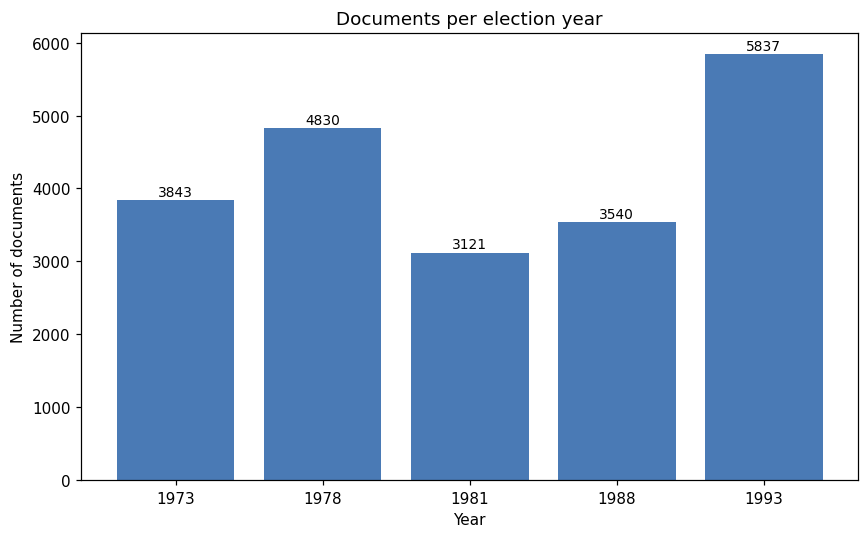

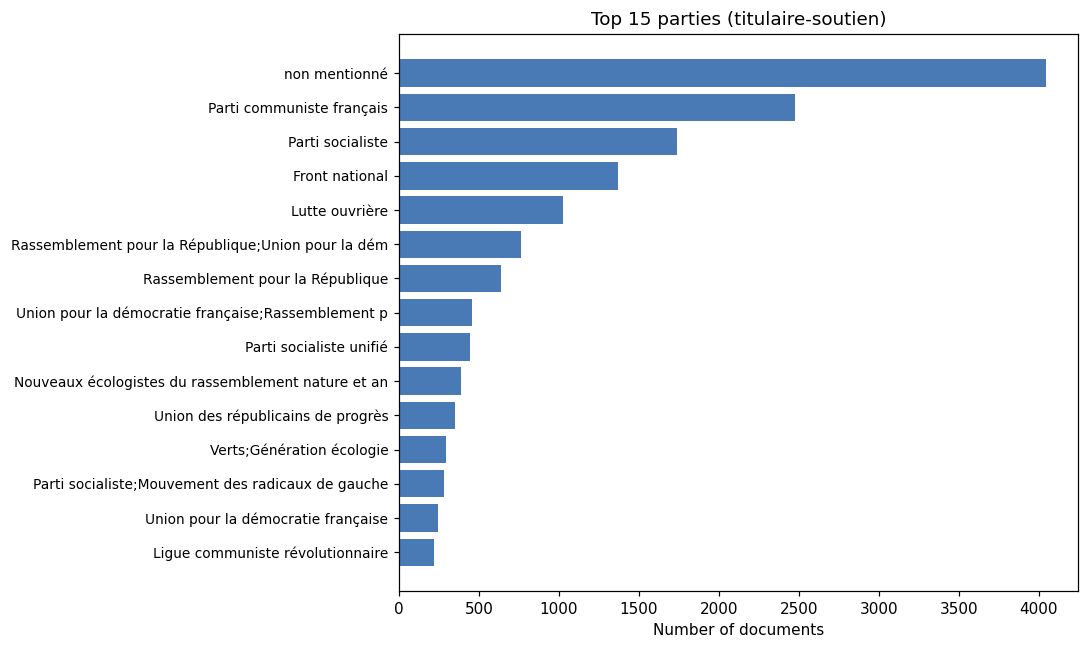

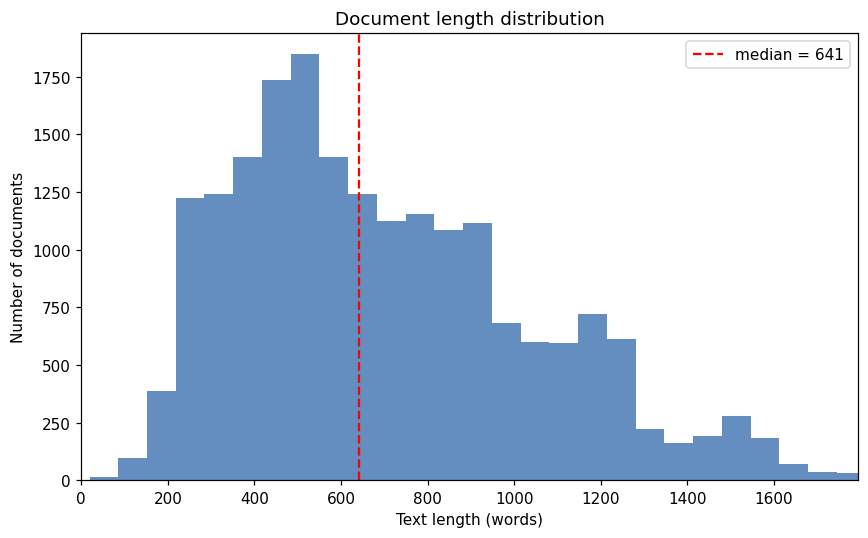

Saved: c:\Users\33768\Desktop\ENSAE\Cours\NLP\projet\Topic_modeling_nlp\outputs\01_data_load\corpus_joined.csv
Saved stats: c:\Users\33768\Desktop\ENSAE\Cours\NLP\projet\Topic_modeling_nlp\outputs\01_data_load\reports\data_info.txt


In [2]:
import pandas as pd
from tqdm.auto import tqdm

YEARS = ["1973", "1978", "1981", "1988", "1993"]

STEP01_DIR = OUTPUTS / "01_data_load"
REPORTS_DIR = STEP01_DIR / "reports"
FIG_DIR = STEP01_DIR / "figures"
for d in (STEP01_DIR, REPORTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = STEP01_DIR / "corpus_joined.csv"
STATS_PATH = REPORTS_DIR / "data_info.txt"

YEAR_DIR_HINTS = {
    "1973": ["1973", "legislatives73"],
    "1978": ["1978", "legislatives78"],
    "1981": ["1981", "legislatives81"],
    "1988": ["1988", "legislatives88"],
    "1993": ["1993", "legislatives93"],
}

def _find_year_dirs(text_root: Path, year: str):
    hints = YEAR_DIR_HINTS.get(year, [year])
    return [text_root / h for h in hints if (text_root / h).exists()]

def load_metadata(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, dtype=str)
    df.columns = [c.strip().lower() for c in df.columns]
    if "contexte-election" in df.columns:
        df = df[df["contexte-election"] == "législatives"].copy()
    df["year"] = df["date"].str[:4]
    df = df[df["year"].isin(YEARS)].copy()
    return df

def build_id_to_path(text_root: Path) -> dict:
    id_to_path = {}
    for year in YEARS:
        year_dirs = _find_year_dirs(text_root, year)
        if not year_dirs:
            print(f"No dir found for year {year} under {text_root}")
            continue
        for year_dir in year_dirs:
            for p in tqdm(list(year_dir.rglob("*.txt")), desc=f"Index {year_dir.name}"):
                id_to_path[p.stem] = p
    return id_to_path

def load_text_file(path):
    if pd.isna(path) or path is None:
        return None
    try:
        return Path(path).read_text(encoding="utf-8", errors="replace")
    except Exception:
        return None

def run_step_01():
    print("Loading metadata...")
    df = load_metadata(CSV_PATH)

    print("Mapping text files...")
    id_to_path = build_id_to_path(TEXT_ROOT)

    df["text_path"] = df["id"].map(id_to_path)
    df["text"] = df["text_path"].apply(load_text_file)
    df["text_length"] = df["text"].apply(
        lambda x: len(x.split()) if isinstance(x, str) else 0
    )

    cols = [
        "id", "date", "year", "contexte-tour",
        "titulaire-liste", "titulaire-soutien",
        "titulaire-sexe", "titulaire-prenom", "titulaire-nom",
        "text", "text_length",
    ]
    cols = [c for c in cols if c in df.columns]
    df = df[cols].copy()

    df.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

    with open(STATS_PATH, "w", encoding="utf-8") as f:
        f.write("===== DATASET INFO =====\n\n")
        f.write(f"Documents total : {len(df)}\n")
        f.write(f"Textes trouvés : {df['text'].notna().sum()}\n")
        f.write(f"Textes manquants : {df['text'].isna().sum()}\n")
        f.write(f"Taux manquant : {df['text'].isna().mean():.3f}\n\n")
        f.write("===== LONGUEUR DES TEXTES =====\n\n")
        f.write(str(df["text_length"].describe()))
        f.write("\n\n")
        f.write("===== PAR ANNEE =====\n\n")
        f.write(str(df["year"].value_counts().sort_index()))
        f.write("\n\n")

    counts = df["year"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(counts.index.astype(str), counts.values, color="#4a7ab5")
    ax.set_title("Documents per election year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Number of documents")
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    if "titulaire-soutien" in df.columns:
        top_parties = df["titulaire-soutien"].value_counts().head(15)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(range(len(top_parties))[::-1], top_parties.values, color="#4a7ab5")
        ax.set_yticks(range(len(top_parties))[::-1])
        ax.set_yticklabels([str(s)[:50] for s in top_parties.index], fontsize=9)
        ax.set_title("Top 15 parties (titulaire-soutien)")
        ax.set_xlabel("Number of documents")
        plt.tight_layout()
        plt.show()

    valid = df[df["text_length"] > 0]["text_length"]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(valid, bins=60, color="#4a7ab5", alpha=0.85)
    ax.axvline(valid.median(), color="red", linestyle="--", label=f"median = {int(valid.median())}")
    ax.set_xlabel("Text length (words)")
    ax.set_ylabel("Number of documents")
    ax.set_title("Document length distribution")
    ax.set_xlim(0, valid.quantile(0.99))
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Saved:", OUTPUT_PATH)
    print("Saved stats:", STATS_PATH)
    return df

RUN_STEP_01 = True
if RUN_STEP_01:
    df_step01 = run_step_01()

## 02 - EDA: top words by year and party

In [ ]:
import pandas as pd
import re
import unicodedata
from collections import Counter
from itertools import chain
from typing import Iterable, List

import matplotlib.pyplot as plt

STEP02_DIR = OUTPUTS / "02_eda"
FIG_DIR = STEP02_DIR / "figures"
REPORTS_DIR = STEP02_DIR / "reports"
for d in (STEP02_DIR, FIG_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

INPUT_PATH = OUTPUTS / "01_data_load" / "corpus_joined.csv"
STOPWORDS_PATH = PROJECT_ROOT / "stop_word_fr.txt"

INFO_PATH = REPORTS_DIR / "eda_info.txt"
TOP_WORDS_YEAR_PATH = STEP02_DIR / "eda_top_words_by_year.csv"
TOP_WORDS_PARTY_PATH = STEP02_DIR / "eda_top_words_by_party.csv"
KEYWORD_TRENDS_PATH = STEP02_DIR / "eda_keyword_trends.csv"

TEXT_COL = "text"
YEAR_COL = "year"
DEFAULT_PARTY_COL = "titulaire-soutien"

EDA_TOPN = 20
EDA_MIN_WORD_LEN = 3
EDA_MIN_DOCS_PER_PARTY = 10
EDA_KEYWORDS = ["travail", "emploi", "republique", "immigration", "securite", "europe"]
EDA_USE_STOPWORDS = True

def strip_accents(text: str) -> str:
    if not isinstance(text, str):
        return ""
    return (
        unicodedata.normalize("NFKD", text)
        .encode("ascii", "ignore")
        .decode("ascii")
    )

def load_stopwords(path: Path) -> set[str]:
    if not path.exists():
        return set()
    words = set()
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            word = line.strip().lower()
            if word:
                words.add(strip_accents(word))
    return words

def tokenize(text: str, min_len: int, stopwords: set[str]) -> List[str]:
    if not isinstance(text, str) or not text.strip():
        return []
    text = strip_accents(text.lower())
    tokens = re.findall(r"[a-z]+", text)
    tokens = [t for t in tokens if len(t) >= min_len]
    if stopwords:
        tokens = [t for t in tokens if t not in stopwords]
    return tokens

def top_words_by_group(df: pd.DataFrame, group_col: str, topn: int) -> pd.DataFrame:
    rows = []
    for group_value, sub in df.groupby(group_col):
        tokens = list(chain.from_iterable(sub["tokens"]))
        if not tokens:
            continue
        counts = Counter(tokens)
        total = sum(counts.values())
        for word, count in counts.most_common(topn):
            rows.append({
                group_col: group_value,
                "word": word,
                "count": count,
                "share": count / total,
            })
    return pd.DataFrame(rows)

def keyword_trends_by_year(df: pd.DataFrame, year_col: str, keywords: Iterable[str]) -> pd.DataFrame:
    keywords = [strip_accents(k.lower()) for k in keywords]
    rows = []
    for year_value, sub in df.groupby(year_col):
        tokens = list(chain.from_iterable(sub["tokens"]))
        total = len(tokens)
        counts = Counter(tokens)
        for kw in keywords:
            rows.append({
                year_col: year_value,
                "keyword": kw,
                "count": counts.get(kw, 0),
                "share": counts.get(kw, 0) / total if total else 0.0,
            })
    return pd.DataFrame(rows)

def plot_keyword_trends(df: pd.DataFrame, year_col: str) -> None:
    if df.empty:
        return
    plt.figure(figsize=(9, 5))
    for keyword, sub in df.groupby("keyword"):
        sub = sub.sort_values(year_col)
        plt.plot(sub[year_col].astype(str), sub["share"], marker="o", label=keyword)
    plt.title("Keyword share by year")
    plt.xlabel("Year")
    plt.ylabel("Share of tokens")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

def run_step_02(
    party_col: str = DEFAULT_PARTY_COL,
    topn: int = EDA_TOPN,
    min_word_len: int = EDA_MIN_WORD_LEN,
    min_docs_per_party: int = EDA_MIN_DOCS_PER_PARTY,
    keywords: Iterable[str] = EDA_KEYWORDS,
    use_stopwords: bool = EDA_USE_STOPWORDS,
):
    print("Loading corpus...")
    df = pd.read_csv(INPUT_PATH)
    if TEXT_COL not in df.columns or YEAR_COL not in df.columns:
        raise ValueError("Missing required columns in corpus_joined.csv")
    if party_col not in df.columns:
        raise ValueError(f"Party column not found: {party_col}")

    stopwords = load_stopwords(STOPWORDS_PATH) if use_stopwords else set()
    print("Tokenizing...")
    df["tokens"] = df[TEXT_COL].apply(lambda x: tokenize(x, min_len=min_word_len, stopwords=stopwords))

    print("Computing top words by year...")
    top_year = top_words_by_group(df, YEAR_COL, topn)
    top_year.to_csv(TOP_WORDS_YEAR_PATH, index=False, encoding="utf-8-sig")

    print("Computing top words by party...")
    party_counts = df[party_col].value_counts(dropna=False)
    allowed_parties = party_counts[party_counts >= min_docs_per_party].index
    df_party = df[df[party_col].isin(allowed_parties)].copy()
    top_party = top_words_by_group(df_party, party_col, topn)
    top_party.to_csv(TOP_WORDS_PARTY_PATH, index=False, encoding="utf-8-sig")

    print("Computing keyword trends...")
    trends = keyword_trends_by_year(df, YEAR_COL, keywords)
    trends.to_csv(KEYWORD_TRENDS_PATH, index=False, encoding="utf-8-sig")
    plot_keyword_trends(trends, YEAR_COL)

    with open(INFO_PATH, "w", encoding="utf-8") as f:
        f.write("=== EDA SUMMARY ===\n\n")
        f.write(f"Documents: {len(df)}\n")
        f.write(f"Year column: {YEAR_COL}\n")
        f.write(f"Party column: {party_col}\n")
        f.write(f"Min word length: {min_word_len}\n")
        f.write(f"Top N words: {topn}\n")
        f.write(f"Stopwords used: {use_stopwords}\n")
        f.write(f"Min docs per party: {min_docs_per_party}\n")
        f.write(f"Keywords: {', '.join(list(keywords))}\n\n")
        f.write("Top words by year saved to: eda_top_words_by_year.csv\n")
        f.write("Top words by party saved to: eda_top_words_by_party.csv\n")
        f.write("Keyword trends saved to: eda_keyword_trends.csv\n")

    print("Saved:", TOP_WORDS_YEAR_PATH)
    print("Saved:", TOP_WORDS_PARTY_PATH)
    print("Saved:", KEYWORD_TRENDS_PATH)
    return top_year, top_party, trends

RUN_STEP_02 = True
if RUN_STEP_02:
    top_year, top_party, trends = run_step_02()

## 03 - OCR quality and lexical diagnostics

In [ ]:
import pandas as pd
import re
from collections import Counter

import matplotlib.pyplot as plt

STEP03_DIR = OUTPUTS / "03_data_quality"
FIG_DIR = STEP03_DIR / "figures"
REPORTS_DIR = STEP03_DIR / "reports"
for d in (STEP03_DIR, FIG_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

INPUT_PATH = OUTPUTS / "01_data_load" / "corpus_joined.csv"
OUTPUT_PATH = STEP03_DIR / "corpus_cleaned.csv"
STATS_PATH = REPORTS_DIR / "ocr_quality.txt"

COMMON_WORDS = set([
    "le", "la", "les", "de", "des", "du", "un", "une", "et", "en", "a", "pour",
    "avec", "dans", "sur", "plus", "mais", "ou", "donc", "car", "ni", "si",
    "est", "sont", "etre", "avoir", "fait", "par", "comme", "meme",
    "france", "politique", "election", "candidat", "vote", "republique",
    "travail", "emploi", "social", "economie", "securite", "nation",
])

DIAGNOSTIC_STOPWORDS = set("""
le la les de des du un une et en a au aux ce ces son ses sa se ne pas que qui
il elle on nous vous ils elles je tu est sont par pour sur avec dans plus mais
ou ou donc car ni si tout tous toute toutes tres bien aussi comme meme sans
sous entre vers chez cette cet dont peut apres avant encore autre autres peu
puis ete faire avoir fait dit lors non oui quand quel quelle quels quelles
ont sera faut doit deja depuis ainsi jusque jusqu chaque ceux celles celui celle
alors notre votre leur leurs mes tes mon ma ton ta lui eux moi toi ici la
""".split())

def extract_tokens(text: str) -> list[str]:
    if not isinstance(text, str):
        return []
    return re.findall(r"[a-zàâäéèêëîïôöùûüçœæ]+", text.lower())

def evaluate_text(text):
    tokens = extract_tokens(text)
    n = len(tokens)
    if n == 0:
        return {"tokens": 0, "known_ratio": 0, "short_ratio": 1, "score": 0}
    known_ratio = sum(t in COMMON_WORDS for t in tokens) / n
    short_ratio = sum(len(t) <= 2 for t in tokens) / n
    score = 0.7 * known_ratio + 0.3 * (1 - short_ratio)
    return {"tokens": n, "known_ratio": known_ratio, "short_ratio": short_ratio, "score": score}

def make_quality_plots(df: pd.DataFrame):
    fig, ax = plt.subplots(figsize=(8, 5))
    df.boxplot(column="score", by="year", grid=False, ax=ax)
    ax.set_title("OCR quality score by year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Score")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    df.boxplot(column="tokens", by="year", grid=False, showfliers=False, ax=ax)
    ax.set_title("Document length by year")
    ax.set_xlabel("Year")
    ax.set_ylabel("Tokens")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df["score"], bins=40)
    ax.set_title("OCR score distribution")
    ax.set_xlabel("Score")
    ax.set_ylabel("Documents")
    plt.tight_layout()
    plt.show()

    keep_by_year = df.groupby(["year", "keep"]).size().unstack(fill_value=0)
    keep_by_year.plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title("Kept vs removed documents")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

def make_lexical_diagnostic_plots(df: pd.DataFrame):
    all_tokens = []
    for text in df["text"].dropna():
        all_tokens.extend(extract_tokens(text))
    token_counts = Counter(all_tokens)
    total_tokens = sum(token_counts.values())
    if total_tokens == 0:
        print("No tokens found for lexical diagnostics.")
        return

    top_words = token_counts.most_common(30)
    words = [w for w, _ in top_words]
    counts = [c for _, c in top_words]
    plt.figure(figsize=(10, 7))
    plt.barh(words[::-1], counts[::-1])
    plt.title("Most frequent words before stopword removal")
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()

    stopword_counts = {w: c for w, c in token_counts.items() if w in DIAGNOSTIC_STOPWORDS}
    top_stopwords = Counter(stopword_counts).most_common(30)
    if top_stopwords:
        words = [w for w, _ in top_stopwords]
        counts = [c for _, c in top_stopwords]
        plt.figure(figsize=(10, 7))
        plt.barh(words[::-1], counts[::-1])
        plt.title("Most frequent stopwords before preprocessing")
        plt.xlabel("Frequency")
        plt.tight_layout()
        plt.show()

    rows = []
    for year, sub in df.groupby("year"):
        year_tokens = []
        for text in sub["text"].dropna():
            year_tokens.extend(extract_tokens(text))
        if len(year_tokens) == 0:
            continue
        stop_count = sum(t in DIAGNOSTIC_STOPWORDS for t in year_tokens)
        rows.append({
            "year": year,
            "stopword_share": stop_count / len(year_tokens),
            "n_tokens": len(year_tokens),
        })
    stop_df = pd.DataFrame(rows)
    if len(stop_df) > 0:
        plt.figure(figsize=(8, 5))
        plt.bar(stop_df["year"].astype(str), stop_df["stopword_share"])
        plt.title("Share of stopwords by year")
        plt.xlabel("Year")
        plt.ylabel("Stopword share")
        plt.tight_layout()
        plt.show()

    sorted_counts = [c for _, c in token_counts.most_common(100)]
    cumulative = pd.Series(sorted_counts).cumsum() / total_tokens
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(cumulative) + 1), cumulative)
    plt.title("Cumulative share of top 100 words")
    plt.xlabel("Top N words")
    plt.ylabel("Cumulative share of all tokens")
    plt.tight_layout()
    plt.show()

    lexical_stats_path = REPORTS_DIR / "lexical_diagnostics.txt"
    with open(lexical_stats_path, "w", encoding="utf-8") as f:
        f.write("=== LEXICAL DIAGNOSTICS BEFORE STOPWORD REMOVAL ===\n\n")
        f.write(f"Total tokens: {total_tokens}\n")
        f.write(f"Unique tokens: {len(token_counts)}\n\n")
        f.write("Top 50 words:\n")
        for word, count in token_counts.most_common(50):
            f.write(f"{word}: {count} ({count / total_tokens:.4%})\n")
        f.write("\nTop 50 diagnostic stopwords:\n")
        for word, count in Counter(stopword_counts).most_common(50):
            f.write(f"{word}: {count} ({count / total_tokens:.4%})\n")
        if len(stop_df) > 0:
            f.write("\nStopword share by year:\n")
            f.write(stop_df.to_string(index=False))
            f.write("\n")
    print(f"Saved lexical diagnostics -> {lexical_stats_path}")

def run_step_03():
    print("Loading dataset...")
    df = pd.read_csv(INPUT_PATH)
    if "text" not in df.columns:
        raise ValueError("Missing column: text")
    print("Computing OCR quality...")
    metrics = df["text"].apply(evaluate_text).apply(pd.Series)
    df = pd.concat([df, metrics], axis=1)
    df["keep"] = (df["tokens"] > 50) & (df["short_ratio"] < 0.5)
    df_clean = df[df["keep"]].copy()

    with open(STATS_PATH, "w", encoding="utf-8") as f:
        f.write("=== OCR QUALITY ===\n\n")
        f.write(f"Total documents: {len(df)}\n")
        f.write(f"Kept documents: {len(df_clean)}\n")
        f.write(f"Removed: {len(df) - len(df_clean)}\n\n")
        f.write("Average score:\n")
        f.write(str(df.groupby("year")["score"].mean()))
        f.write("\n\n")
        f.write("Median length:\n")
        f.write(str(df.groupby("year")["tokens"].median()))
        f.write("\n")

    print("Generating plots...")
    make_quality_plots(df)
    make_lexical_diagnostic_plots(df_clean)
    df_clean.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")
    print("Saved dataset ->", OUTPUT_PATH)
    print("Saved stats ->", STATS_PATH)
    return df_clean

RUN_STEP_03 = True
if RUN_STEP_03:
    df_step03 = run_step_03()

## 04 - Preprocessing (clean, lemmatize, remove stopwords)

In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

STEP04_DIR = OUTPUTS / "04_preprocessing"
REPORTS_DIR = STEP04_DIR / "reports"
FIG_DIR = STEP04_DIR / "figures"
for d in (STEP04_DIR, REPORTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

INPUT_PATH = OUTPUTS / "03_data_quality" / "corpus_cleaned.csv"
OUTPUT_PATH = STEP04_DIR / "corpus_preprocessed.csv"
INFO_PATH = REPORTS_DIR / "preprocessing_info.txt"

try:
    step04 = load_script_module("04_preprocessing.py", "step04")
except OSError as exc:
    raise OSError("spaCy model missing. Run: python -m spacy download fr_core_news_sm") from exc

def run_step_04():
    print("Loading corpus...")
    df = pd.read_csv(INPUT_PATH)
    if "text" not in df.columns:
        raise ValueError("Column 'text' is missing from the input file.")
    tqdm.pandas(desc="Cleaning")
    df["text_clean"] = df["text"].progress_apply(step04.light_clean)
    print("Lemmatizing...")
    df["text_lemmatized"] = step04.lemmatize_batch(df["text_clean"].tolist())
    print("Removing stopwords...")
    tqdm.pandas(desc="Stopwords")
    df["text_preprocessed"] = df["text_lemmatized"].progress_apply(step04.remove_stopwords)
    df = df.drop(columns=["text_lemmatized"])

    df["tokens_before"] = df["text"].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)
    df["tokens_clean"] = df["text_clean"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)
    df["tokens_after"] = df["text_preprocessed"].apply(lambda x: len(x.split()) if isinstance(x, str) else 0)

    df["preprocess_keep"] = df["tokens_after"] >= 30
    df_final = df[df["preprocess_keep"]].copy()

    with open(INFO_PATH, "w", encoding="utf-8") as f:
        f.write("=== PREPROCESSING INFO ===\n\n")
        f.write(f"Initial documents: {len(df)}\n")
        f.write(f"Documents kept: {len(df_final)}\n")
        f.write(f"Documents removed: {len(df) - len(df_final)}\n")
        f.write(f"Stopwords used: {len(step04.STOPWORDS)}\n\n")
        f.write("=== TOKEN COUNTS ===\n\n")
        f.write(f"Average tokens (text): {df['tokens_before'].mean():.2f}\n")
        f.write(f"Average tokens (text_clean): {df['tokens_clean'].mean():.2f}\n")
        f.write(f"Average tokens (text_preprocessed): {df['tokens_after'].mean():.2f}\n")
        if df["tokens_before"].mean() > 0:
            reduction = 100 * (1 - df["tokens_after"].mean() / df["tokens_before"].mean())
            f.write(f"Average reduction (raw -> preprocessed): {reduction:.2f}%\n\n")
        f.write("Token distribution (preprocessed):\n")
        f.write(df["tokens_after"].describe().to_string())
        f.write("\n\n")
        if "year" in df.columns:
            f.write("=== TOKENS BY YEAR (preprocessed) ===\n\n")
            f.write(
                df.groupby("year")["tokens_after"]
                .describe()[["count", "mean", "min", "50%", "max"]]
                .to_string()
            )
            f.write("\n\n")
        f.write("=== POLITICAL WORDS KEPT ===\n\n")
        f.write(", ".join(sorted(step04.POLITICAL_WORDS_TO_KEEP)))
        f.write("\n")

    df_final.to_csv(OUTPUT_PATH, index=False, encoding="utf-8-sig")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if "year" in df_final.columns:
        years = sorted(df_final["year"].dropna().unique())
        before_data = [df_final[df_final["year"] == y]["tokens_clean"].values for y in years]
        after_data = [df_final[df_final["year"] == y]["tokens_after"].values for y in years]
        positions_b = [i - 0.2 for i in range(len(years))]
        positions_a = [i + 0.2 for i in range(len(years))]
        bp1 = axes[0].boxplot(before_data, positions=positions_b, widths=0.35, patch_artist=True, showfliers=False)
        bp2 = axes[0].boxplot(after_data, positions=positions_a, widths=0.35, patch_artist=True, showfliers=False)
        for box in bp1["boxes"]:
            box.set_facecolor("#a6c8ed")
        for box in bp2["boxes"]:
            box.set_facecolor("#4a7ab5")
        axes[0].set_xticks(range(len(years)))
        axes[0].set_xticklabels([str(y) for y in years])
        axes[0].set_xlabel("Year")
        axes[0].set_ylabel("Tokens per document")
        axes[0].set_title("Token count before vs after per year")
        axes[0].legend([bp1["boxes"][0], bp2["boxes"][0]], ["text_clean", "text_preprocessed"], loc="upper right")

    df_final["reduction_pct"] = 100 * (1 - df_final["tokens_after"] / df_final["tokens_clean"].replace(0, np.nan))
    axes[1].hist(df_final["reduction_pct"].dropna(), bins=40, color="#4a7ab5", alpha=0.85)
    axes[1].axvline(df_final["reduction_pct"].median(), color="red", linestyle="--",
                    label=f"median = {df_final['reduction_pct'].median():.1f}%")
    axes[1].set_xlabel("Token reduction (%)")
    axes[1].set_ylabel("Number of documents")
    axes[1].set_title("Token reduction after preprocessing")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    print("Saved corpus:", OUTPUT_PATH)
    print("Saved info:", INFO_PATH)
    return df_final

RUN_STEP_04 = True
if RUN_STEP_04:
    df_step04 = run_step_04()

## 05 - Chunking methods evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

step05 = load_script_module("05_chunking_eval.py", "step05")

STEP05_DIR = OUTPUTS / "05_chunking_eval"
REPORTS_DIR = STEP05_DIR / "reports"
FIG_DIR = STEP05_DIR / "figures"
for d in (STEP05_DIR, REPORTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

INPUT_PATH = OUTPUTS / "04_preprocessing" / "corpus_preprocessed.csv"

TEXT_COL = "text_clean"
SAMPLE = 200
MIN_WORDS = 20
FIXED_SIZES = [100, 150, 200, 300]
OVERLAP = 30
TOPN = 10
RANDOM_STATE = 42

def run_step_05(
    text_col: str = TEXT_COL,
    sample: int = SAMPLE,
    min_words: int = MIN_WORDS,
    fixed_sizes: list[int] = FIXED_SIZES,
    overlap: int = OVERLAP,
    topn: int = TOPN,
    random_state: int = RANDOM_STATE,
    output_csv: Path | None = None,
    output_txt: Path | None = None,
    ):
    if output_csv is None:
        output_csv = STEP05_DIR / "chunking_methods_eval.csv"
    if output_txt is None:
        output_txt = REPORTS_DIR / "chunking_methods_eval.txt"
    df = pd.read_csv(INPUT_PATH)
    if text_col not in df.columns:
        raise ValueError(f"Column not found: {text_col}")
    df = df[df[text_col].notna()].copy()
    if sample and sample > 0 and len(df) > sample:
        df = df.sample(n=sample, random_state=random_state)
    texts = df[text_col].astype(str).tolist()
    results = []

    sentence_chunks = []
    for text in texts:
        sentence_chunks.extend(step05.chunk_by_sentence(text, min_words=min_words))
    results.append({"method": "sentence", **step05.compute_stats(sentence_chunks, topn=topn)})

    paragraph_chunks = []
    for text in texts:
        paragraph_chunks.extend(step05.chunk_by_paragraph(text, min_words=min_words))
    results.append({"method": "paragraph", **step05.compute_stats(paragraph_chunks, topn=topn)})

    for size in fixed_sizes:
        chunks_no_overlap = []
        for text in texts:
            chunks_no_overlap.extend(
                step05.chunk_by_fixed_length(text, chunk_size=size, min_words=min_words, overlap=0)
            )
        results.append({"method": f"fixed_{size}", **step05.compute_stats(chunks_no_overlap, topn=topn)})

        chunks_overlap = []
        for text in texts:
            chunks_overlap.extend(
                step05.chunk_by_fixed_length(text, chunk_size=size, min_words=min_words, overlap=overlap)
            )
        results.append({"method": f"fixed_{size}_ov{overlap}", **step05.compute_stats(chunks_overlap, topn=topn)})

    df_res = pd.DataFrame(results)
    df_res["combined_score"] = df_res["coherence_c_v"] * df_res["topic_diversity"]
    df_sorted = df_res.sort_values(by="combined_score", ascending=False)

    df_sorted.to_csv(output_csv, index=False, encoding="utf-8-sig")
    with open(output_txt, "w", encoding="utf-8") as f:
        f.write("=== CHUNKING METHODS EVALUATION ===\n\n")
        f.write(f"Input: {INPUT_PATH}\n")
        f.write(f"Text column: {text_col}\n")
        f.write(f"Documents used: {len(texts)}\n")
        f.write(f"Min words per chunk: {min_words}\n")
        f.write(f"Fixed sizes: {fixed_sizes} (overlap variant: {overlap})\n")
        f.write(f"Topn words per chunk: {topn}\n\n")
        f.write(df_sorted.to_string(index=False))
        f.write("\n")

    valid = df_sorted.dropna(subset=["coherence_c_v", "topic_diversity"])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for _, r in valid.iterrows():
        color = "#c44e52" if "fixed" in str(r["method"]) else "#4a7ab5"
        axes[0].scatter(r["coherence_c_v"], r["topic_diversity"], s=80, color=color)
        axes[0].annotate(str(r["method"]), (r["coherence_c_v"], r["topic_diversity"]),
                         fontsize=8, xytext=(5, 5), textcoords="offset points")
    axes[0].set_xlabel("Coherence (c_v)")
    axes[0].set_ylabel("Topic diversity")
    axes[0].set_title("Chunking method: coherence vs topic diversity")
    axes[0].grid(alpha=0.3)

    df_plot = valid.sort_values("combined_score", ascending=True)
    axes[1].barh(range(len(df_plot)), df_plot["combined_score"].values, color="#4a7ab5")
    axes[1].set_yticks(range(len(df_plot)))
    axes[1].set_yticklabels(df_plot["method"].values, fontsize=9)
    axes[1].set_xlabel("Combined score (coherence x diversity)")
    axes[1].set_title("Chunking methods ranked")
    plt.tight_layout()
    plt.show()

    print("Saved:", output_csv)
    print("Saved:", output_txt)
    return df_sorted

RUN_STEP_05 = True
if RUN_STEP_05:
    eval_df = run_step_05()

## 06 - Chunking and embeddings

In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import torch
from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt

step06 = load_script_module("06_chunking_embedding.py", "step06")

STEP06_DIR = OUTPUTS / "06_chunking_embedding"
REPORTS_DIR = STEP06_DIR / "reports"
FIG_DIR = STEP06_DIR / "figures"
for d in (STEP06_DIR, REPORTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

INPUT_PATH = OUTPUTS / "04_preprocessing" / "corpus_preprocessed.csv"
CHUNKS_PATH = STEP06_DIR / "corpus_chunks.csv"
EMBEDDINGS_PATH = STEP06_DIR / "chunk_embeddings.npy"
INFO_PATH = REPORTS_DIR / "chunking_embedding_info.txt"

TEXT_COL = "text_clean"
CHUNK_SIZE = step06.CHUNK_SIZE
CHUNK_OVERLAP = step06.CHUNK_OVERLAP
MIN_CHUNK_WORDS = step06.MIN_CHUNK_WORDS
MODEL_NAME = step06.MODEL_NAME

if torch.cuda.is_available():
    DEVICE = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

def run_step_06():
    df = pd.read_csv(INPUT_PATH)
    if TEXT_COL not in df.columns:
        raise ValueError(f"Missing text column: {TEXT_COL}. Run step 04 first.")
    rows = []
    metadata_cols = [
        "id", "date", "year", "contexte-tour",
        "titulaire-liste", "titulaire-soutien",
        "titulaire-sexe", "titulaire-prenom", "titulaire-nom",
    ]
    metadata_cols = [c for c in metadata_cols if c in df.columns]
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Chunking"):
        chunks = step06.split_into_chunks(
            row[TEXT_COL],
            chunk_size=CHUNK_SIZE,
            overlap=CHUNK_OVERLAP,
            min_words=MIN_CHUNK_WORDS,
        )
        for i, chunk in enumerate(chunks):
            new_row = {col: row[col] for col in metadata_cols}
            new_row["doc_id"] = row["id"]
            new_row["chunk_id"] = f"{row['id']}_chunk_{i:03d}"
            new_row["chunk_index"] = i
            new_row["chunk_text"] = chunk
            new_row["chunk_words"] = len(chunk.split())
            rows.append(new_row)
    df_chunks = pd.DataFrame(rows)
    df_chunks.to_csv(CHUNKS_PATH, index=False, encoding="utf-8-sig")
    print(f"Chunks created: {len(df_chunks)}")
    print(f"Saved chunks: {CHUNKS_PATH}")

    print("Loading embedding model...")
    model = SentenceTransformer(MODEL_NAME, device=DEVICE)
    print("Computing embeddings...")
    embeddings = model.encode(
        df_chunks["chunk_text"].tolist(),
        batch_size=128 if DEVICE != "cpu" else 32,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    np.save(EMBEDDINGS_PATH, embeddings)
    print("Saved embeddings:", EMBEDDINGS_PATH)
    print("Embedding shape:", embeddings.shape)

    with open(INFO_PATH, "w", encoding="utf-8") as f:
        f.write("=== CHUNKING + EMBEDDING INFO ===\n\n")
        f.write(f"Input column: {TEXT_COL}\n")
        f.write(f"Input documents: {len(df)}\n")
        f.write(f"Chunks created: {len(df_chunks)}\n")
        f.write(f"Average chunks per document: {len(df_chunks) / max(1, len(df)):.2f}\n\n")
        f.write(f"Chunk size: {CHUNK_SIZE}\n")
        f.write(f"Chunk overlap: {CHUNK_OVERLAP}\n")
        f.write(f"Minimum chunk words: {MIN_CHUNK_WORDS}\n\n")
        f.write(f"Device: {DEVICE}\n")
        f.write(f"Embedding model: {MODEL_NAME}\n")
        f.write(f"Embedding matrix shape: {embeddings.shape}\n\n")
        f.write("Chunk length distribution:\n")
        f.write(df_chunks["chunk_words"].describe().to_string())
        f.write("\n\n")
        if "year" in df_chunks.columns:
            f.write("Chunks by year:\n")
            f.write(df_chunks["year"].value_counts().sort_index().to_string())
            f.write("\n\n")
        if "titulaire-soutien" in df_chunks.columns:
            f.write("Top political supports by chunks:\n")
            f.write(df_chunks["titulaire-soutien"].value_counts().head(20).to_string())
            f.write("\n")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    chunks_per_doc = df_chunks.groupby("doc_id").size()
    axes[0].hist(chunks_per_doc.values, bins=40, color="#4a7ab5", alpha=0.85)
    axes[0].axvline(chunks_per_doc.median(), color="red", linestyle="--",
                    label=f"median = {int(chunks_per_doc.median())}")
    axes[0].set_xlabel("Chunks per document")
    axes[0].set_ylabel("Number of documents")
    axes[0].set_title(f"Chunks per document (n={len(df_chunks)} chunks total)")
    axes[0].legend()
    if "year" in df_chunks.columns:
        per_year = df_chunks["year"].value_counts().sort_index()
        axes[1].bar(per_year.index.astype(str), per_year.values, color="#4a7ab5")
        axes[1].set_xlabel("Year")
        axes[1].set_ylabel("Number of chunks")
        axes[1].set_title("Chunks per election year")
        for i, v in enumerate(per_year.values):
            axes[1].text(i, v + max(per_year.values) * 0.01, str(v), ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

    return df_chunks, embeddings

RUN_STEP_06 = True
if RUN_STEP_06:
    df_chunks, chunk_embeddings = run_step_06()

## 07 - BERTopic topic modeling

In [ ]:
import numpy as np
import pandas as pd
import torch

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

STEP07_DIR = OUTPUTS / "07_bertopic"
FIG_DIR = STEP07_DIR / "figures"
REPORTS_DIR = STEP07_DIR / "reports"
MODEL_DIR = STEP07_DIR / "models" / "bertopic_model"
for d in (STEP07_DIR, FIG_DIR, REPORTS_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

STOPWORDS_PATH = PROJECT_ROOT / "stop_word_fr.txt"
CHUNKS_PATH = OUTPUTS / "06_chunking_embedding" / "corpus_chunks.csv"
EMBEDDINGS_PATH = OUTPUTS / "06_chunking_embedding" / "chunk_embeddings.npy"

OUTPUT_CHUNKS_PATH = STEP07_DIR / "chunks_with_topics.csv"
TOPIC_INFO_PATH = STEP07_DIR / "topic_info.csv"
INFO_PATH = REPORTS_DIR / "topic_modeling_info.txt"

TEXT_COL = "chunk_text"
MIN_TOPIC_SIZE = 60
N_NEIGHBORS = 30
N_COMPONENTS = 5
MIN_DIST = 0.0
RANDOM_STATE = 42
VECT_MIN_DF = 2
VECT_MAX_DF = 0.5
NGRAM_RANGE = (1, 2)
REDUCE_OUTLIERS = True
SHOW_DOCUMENT_MAP = False

def load_stopwords(path: Path) -> list[str] | None:
    if not path.exists():
        print(f"Warning: stopword file not found at {path}")
        return None
    with open(path, "r", encoding="utf-8") as f:
        words = [line.strip().lower() for line in f if line.strip()]
    return sorted(set(words))

def run_step_07():
    if torch.cuda.is_available():
        device = "cuda"
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = "mps"
    else:
        device = "cpu"
    print(f"Using device: {device}")

    df = pd.read_csv(CHUNKS_PATH)
    embeddings = np.load(EMBEDDINGS_PATH)
    if TEXT_COL not in df.columns:
        raise ValueError(f"Missing column: {TEXT_COL}")
    if len(df) != embeddings.shape[0]:
        raise ValueError("Mismatch between chunks and embeddings")
    docs = df[TEXT_COL].fillna("").astype(str).tolist()

    french_stopwords = load_stopwords(STOPWORDS_PATH)
    vectorizer_model = CountVectorizer(
        stop_words=french_stopwords,
        min_df=VECT_MIN_DF,
        max_df=VECT_MAX_DF,
        ngram_range=NGRAM_RANGE,
    )
    umap_model = UMAP(
        n_neighbors=N_NEIGHBORS,
        n_components=N_COMPONENTS,
        min_dist=MIN_DIST,
        metric="cosine",
        random_state=RANDOM_STATE,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=MIN_TOPIC_SIZE,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    )
    topic_model = BERTopic(
        language="multilingual",
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        calculate_probabilities=False,
        verbose=True,
    )
    print("Fitting BERTopic...")
    topics, _ = topic_model.fit_transform(docs, embeddings)
    n_outliers_before = sum(t == -1 for t in topics)
    print(f"Outliers before reduction: {n_outliers_before}")
    if REDUCE_OUTLIERS and n_outliers_before > 0:
        topics = topic_model.reduce_outliers(
            documents=docs, topics=topics, embeddings=embeddings, strategy="embeddings"
        )
        n_outliers_after = sum(t == -1 for t in topics)
        print(f"Outliers after reduction: {n_outliers_after}")
        topic_model.update_topics(docs=docs, topics=topics, vectorizer_model=vectorizer_model)
        topic_model.reduce_topics(docs, nr_topics=30)

    df["topic"] = topics
    df.to_csv(OUTPUT_CHUNKS_PATH, index=False, encoding="utf-8-sig")
    topic_info = topic_model.get_topic_info()
    topic_info.to_csv(TOPIC_INFO_PATH, index=False, encoding="utf-8-sig")
    topic_model.save(str(MODEL_DIR), serialization="pickle", save_ctfidf=True)

    try:
        fig = topic_model.visualize_barchart(top_n_topics=20)
        fig.show()
    except Exception as e:
        print(f"Could not render topic barchart: {e}")
    try:
        fig = topic_model.visualize_heatmap()
        fig.show()
    except Exception as e:
        print(f"Could not render topic heatmap: {e}")
    try:
        fig = topic_model.visualize_hierarchy()
        fig.show()
    except Exception as e:
        print(f"Could not render topic hierarchy: {e}")

    if SHOW_DOCUMENT_MAP:
        try:
            sample_size = min(5000, len(docs))
            if len(docs) > sample_size:
                rng = np.random.default_rng(RANDOM_STATE)
                sample_idx = rng.choice(len(docs), size=sample_size, replace=False)
                sample_docs = [docs[i] for i in sample_idx]
                sample_embeddings = embeddings[sample_idx]
            else:
                sample_docs = docs
                sample_embeddings = embeddings
            fig = topic_model.visualize_documents(
                docs=sample_docs,
                embeddings=sample_embeddings,
                hide_annotations=True,
                title=f"Document map ({sample_size} chunks, colored by topic)",
            )
            fig.show()
        except Exception as e:
            print(f"Could not render topic documents: {e}")

    sizes = topic_info[topic_info["Topic"] != -1].sort_values("Count", ascending=False).head(30)
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(sizes)), sizes["Count"].values, color="#4a7ab5")
    plt.xticks(range(len(sizes)), sizes["Topic"].astype(int).values, rotation=0, fontsize=8)
    plt.xlabel("Topic id")
    plt.ylabel("Number of chunks")
    plt.title("Top 30 topics by size (chunks)")
    plt.tight_layout()
    plt.show()

    n_topics = len(set(topics)) - (1 if -1 in topics else 0)
    n_outliers = sum(t == -1 for t in topics)
    outlier_rate = n_outliers / len(df)
    with open(INFO_PATH, "w", encoding="utf-8") as f:
        f.write("=== BERTopic Modeling Info ===\n\n")
        f.write(f"Device detected: {device}\n")
        f.write(f"Number of chunks: {len(df)}\n")
        f.write(f"Number of topics excluding outliers: {n_topics}\n")
        f.write(f"Outliers: {n_outliers}\n")
        f.write(f"Outlier rate: {outlier_rate:.3f}\n\n")
        f.write("=== Parameters ===\n")
        f.write(f"MIN_TOPIC_SIZE: {MIN_TOPIC_SIZE}\n")
        f.write(f"N_NEIGHBORS: {N_NEIGHBORS}\n")
        f.write(f"N_COMPONENTS: {N_COMPONENTS}\n")
        f.write(f"MIN_DIST: {MIN_DIST}\n")
        f.write(f"RANDOM_STATE: {RANDOM_STATE}\n")
        f.write(f"VECT_MIN_DF: {VECT_MIN_DF}\n")
        f.write(f"VECT_MAX_DF: {VECT_MAX_DF}\n")
        f.write(f"NGRAM_RANGE: {NGRAM_RANGE}\n")
        f.write(f"Stopwords loaded: {len(french_stopwords) if french_stopwords else 0}\n\n")
        f.write("=== Top Topics ===\n")
        f.write(topic_info.head(30).to_string(index=False))

    print("Saved chunks with topics:", OUTPUT_CHUNKS_PATH)
    print("Saved topic info:", TOPIC_INFO_PATH)
    print("Saved model:", MODEL_DIR)
    print("Saved summary:", INFO_PATH)
    return df, topic_info, topic_model

RUN_STEP_07 = True
if RUN_STEP_07:
    df_topics, topic_info, topic_model = run_step_07()

## 08 - LDA topic modeling

In [ ]:
import pandas as pd
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

step08 = load_script_module("08_lda.py", "step08")

STEP08_DIR = OUTPUTS / "08_lda"
REPORTS_DIR = STEP08_DIR / "reports"
FIG_DIR = STEP08_DIR / "figures"
MODEL_DIR = STEP08_DIR / "models" / "lda_model"
for d in (STEP08_DIR, REPORTS_DIR, FIG_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)

INPUT_PATH = OUTPUTS / "04_preprocessing" / "corpus_preprocessed.csv"
OUTPUT_CHUNKS_PATH = STEP08_DIR / "chunks_with_topics_lda.csv"
TOPIC_INFO_PATH = STEP08_DIR / "lda_topic_info.csv"
INFO_PATH = REPORTS_DIR / "lda_modeling_info.txt"
MODEL_PATH = MODEL_DIR / "lda_model.gensim"
DICT_PATH = MODEL_DIR / "dictionary.gensim"

TEXT_COL = "text_preprocessed"
DOC_ID_COL = "id"
CHUNK_SIZE = step08.CHUNK_SIZE
CHUNK_OVERLAP = step08.CHUNK_OVERLAP
MIN_CHUNK_WORDS = step08.MIN_CHUNK_WORDS
NUM_TOPICS = step08.NUM_TOPICS
PASSES = step08.PASSES
ITERATIONS = step08.ITERATIONS
RANDOM_STATE = step08.RANDOM_STATE
MIN_DF = step08.MIN_DF
MAX_DF = step08.MAX_DF
TOPN_WORDS = step08.TOPN_WORDS

METADATA_COLS = [
    "id", "date", "year", "contexte-tour",
    "titulaire-liste", "titulaire-soutien",
    "titulaire-sexe", "titulaire-prenom", "titulaire-nom",
]

def run_step_08():
    df = pd.read_csv(INPUT_PATH)
    if TEXT_COL not in df.columns:
        raise ValueError(f"Missing column: {TEXT_COL}")
    metadata_cols = [c for c in METADATA_COLS if c in df.columns]
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Chunking"):
        chunks = step08.split_into_chunks(
            row[TEXT_COL],
            chunk_size=CHUNK_SIZE,
            overlap=CHUNK_OVERLAP,
            min_words=MIN_CHUNK_WORDS,
        )
        for i, chunk in enumerate(chunks):
            new_row = {col: row[col] for col in metadata_cols}
            new_row["doc_id"] = row[DOC_ID_COL]
            new_row["chunk_id"] = f"{row[DOC_ID_COL]}_lda_chunk_{i:03d}"
            new_row["chunk_index"] = i
            new_row["chunk_text"] = chunk
            new_row["chunk_words"] = len(chunk.split())
            rows.append(new_row)
    df_chunks = pd.DataFrame(rows)
    print(f"Chunks created: {len(df_chunks)}")

    tokenized = [step08.tokenize(t) for t in df_chunks["chunk_text"].tolist()]
    dictionary = Dictionary(tokenized)
    dictionary.filter_extremes(no_below=MIN_DF, no_above=MAX_DF)
    if len(dictionary) == 0:
        raise ValueError("Empty dictionary after filtering. Adjust MIN_DF/MAX_DF.")
    corpus = [dictionary.doc2bow(t) for t in tokenized]

    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        passes=PASSES,
        iterations=ITERATIONS,
        random_state=RANDOM_STATE,
        eval_every=None,
        alpha="auto",
        eta="auto",
)

    topic_ids = []
    topic_scores = []
    for bow in corpus:
        doc_topics = lda_model.get_document_topics(bow, minimum_probability=0.0)
        topic_id, score = step08.dominant_topic(doc_topics)
        topic_ids.append(topic_id)
        topic_scores.append(score)
    df_chunks["topic_lda"] = topic_ids
    df_chunks["topic_lda_score"] = topic_scores

    topic_rows = []
    for topic_id in range(NUM_TOPICS):
        terms = lda_model.show_topic(topic_id, topn=TOPN_WORDS)
        words = [w for w, _ in terms]
        weights = [float(wt) for _, wt in terms]
        topic_rows.append({
            "topic_id": topic_id,
            "top_words": " ".join(words),
            "top_weights": " ".join(f"{w:.4f}" for w in weights),
        })
    topic_info = pd.DataFrame(topic_rows)

    topics_words = [row["top_words"].split() for row in topic_rows]
    coherence_model = CoherenceModel(
        topics=topics_words,
        texts=tokenized,
        dictionary=dictionary,
        coherence="c_v",
)
    coherence_score = float(coherence_model.get_coherence())

    df_chunks.to_csv(OUTPUT_CHUNKS_PATH, index=False, encoding="utf-8-sig")
    topic_info.to_csv(TOPIC_INFO_PATH, index=False, encoding="utf-8-sig")
    lda_model.save(str(MODEL_PATH))
    dictionary.save(str(DICT_PATH))

    with open(INFO_PATH, "w", encoding="utf-8") as f:
        f.write("=== LDA Topic Modeling Info ===\n\n")
        f.write(f"Number of chunks: {len(df_chunks)}\n")
        f.write(f"Number of topics: {NUM_TOPICS}\n")
        f.write(f"Coherence (c_v): {coherence_score:.4f}\n\n")
        f.write("=== Parameters ===\n")
        f.write(f"CHUNK_SIZE: {CHUNK_SIZE} (overlap {CHUNK_OVERLAP}, min {MIN_CHUNK_WORDS})\n")
        f.write(f"MIN_DF: {MIN_DF}\n")
        f.write(f"MAX_DF: {MAX_DF}\n")
        f.write(f"PASSES: {PASSES}\n")
        f.write(f"ITERATIONS: {ITERATIONS}\n")
        f.write(f"RANDOM_STATE: {RANDOM_STATE}\n")
        f.write(f"TOPN_WORDS: {TOPN_WORDS}\n\n")
        f.write("=== Top Topics ===\n")
        f.write(topic_info.head(30).to_string(index=False))

    cols = 4
    rows = (NUM_TOPICS + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.4 * rows), squeeze=False)
    for tid in range(NUM_TOPICS):
        terms = lda_model.show_topic(tid, topn=10)
        words = [w for w, _ in terms][::-1]
        weights = [float(wt) for _, wt in terms][::-1]
        ax = axes[tid // cols][tid % cols]
        ax.barh(range(len(words)), weights, color="#4a7ab5")
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=8)
        ax.set_title(f"Topic {tid}", fontsize=10)
        ax.tick_params(axis="x", labelsize=7)
    for tid in range(NUM_TOPICS, rows * cols):
        axes[tid // cols][tid % cols].axis("off")
    plt.suptitle(f"LDA - Top 10 words per topic (coherence c_v = {coherence_score:.3f})", fontsize=12, y=1.0)
    plt.tight_layout()
    plt.show()

    topic_counts = pd.Series(topic_ids).value_counts().sort_index()
    plt.figure(figsize=(10, 5))
    plt.bar(topic_counts.index, topic_counts.values, color="#4a7ab5")
    plt.xlabel("Topic id")
    plt.ylabel("Number of chunks (dominant topic)")
    plt.title("LDA - chunks per dominant topic")
    plt.tight_layout()
    plt.show()

    print("Saved chunks with topics:", OUTPUT_CHUNKS_PATH)
    print("Saved topic info:", TOPIC_INFO_PATH)
    print("Saved model:", MODEL_PATH)
    print("Saved summary:", INFO_PATH)
    return df_chunks, topic_info, lda_model

RUN_STEP_08 = True
if RUN_STEP_08:
    df_lda_chunks, lda_topic_info, lda_model = run_step_08()

## 09 - Doc-level topic vectors and party families

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

step09 = load_script_module("09_doc_topic_vectors.py", "step09")

STEP09_DIR = OUTPUTS / "09_doc_topic_vectors"
REPORTS_DIR = STEP09_DIR / "reports"
FIG_DIR = STEP09_DIR / "figures"
for d in (STEP09_DIR, REPORTS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

BERTOPIC_CHUNKS_PATH = OUTPUTS / "07_bertopic" / "chunks_with_topics.csv"
LDA_CHUNKS_PATH = OUTPUTS / "08_lda" / "chunks_with_topics_lda.csv"

BERTOPIC_VEC_PATH = STEP09_DIR / "doc_topic_vectors_bertopic.csv"
LDA_VEC_PATH = STEP09_DIR / "doc_topic_vectors_lda.csv"
PARTY_FAMILY_PATH = STEP09_DIR / "doc_party_family.csv"
INFO_PATH = REPORTS_DIR / "doc_topic_vectors_info.txt"

DOC_ID_COL = "doc_id"
BERTOPIC_TOPIC_COL = "topic"
LDA_TOPIC_COL = "topic_lda"
LDA_SCORE_COL = "topic_lda_score"
DOC_META_COLS = step09.DOC_META_COLS

def run_step_09(include_bertopic_outliers: bool = False, lda_use_score: bool = False):
    df_bert = pd.read_csv(BERTOPIC_CHUNKS_PATH)
    df_lda = pd.read_csv(LDA_CHUNKS_PATH)
    if DOC_ID_COL not in df_bert.columns or BERTOPIC_TOPIC_COL not in df_bert.columns:
        raise ValueError("Missing columns in BERTopic chunks output.")
    if DOC_ID_COL not in df_lda.columns or LDA_TOPIC_COL not in df_lda.columns:
        raise ValueError("Missing columns in LDA chunks output.")

    drop_topics = [] if include_bertopic_outliers else [-1]
    bert_vec = step09.build_doc_topic_matrix(
        df_bert, doc_col=DOC_ID_COL, topic_col=BERTOPIC_TOPIC_COL, weight_col=None, drop_topics=drop_topics
    )
    bert_meta = step09.doc_metadata(df_bert, DOC_ID_COL, DOC_META_COLS)
    bert_meta["party_family"] = bert_meta.apply(step09.assign_party_family, axis=1)
    bert_out = bert_meta.merge(bert_vec.reset_index(), on=DOC_ID_COL, how="left").fillna(0.0)
    topic_cols_bert = [c for c in bert_out.columns if c.startswith("topic_")]
    if topic_cols_bert:
        bert_out["dominant_topic"] = (
            bert_out[topic_cols_bert].idxmax(axis=1).str.replace("topic_", "").astype(int)
        )
    bert_out.to_csv(BERTOPIC_VEC_PATH, index=False, encoding="utf-8-sig")

    weight_col = LDA_SCORE_COL if lda_use_score and LDA_SCORE_COL in df_lda.columns else None
    lda_vec = step09.build_doc_topic_matrix(
        df_lda, doc_col=DOC_ID_COL, topic_col=LDA_TOPIC_COL, weight_col=weight_col, drop_topics=None
    )
    lda_meta = step09.doc_metadata(df_lda, DOC_ID_COL, DOC_META_COLS)
    lda_meta["party_family"] = lda_meta.apply(step09.assign_party_family, axis=1)
    lda_out = lda_meta.merge(lda_vec.reset_index(), on=DOC_ID_COL, how="left").fillna(0.0)
    topic_cols_lda = [c for c in lda_out.columns if c.startswith("topic_")]
    if topic_cols_lda:
        lda_out["dominant_topic"] = (
            lda_out[topic_cols_lda].idxmax(axis=1).str.replace("topic_", "").astype(int)
        )
    lda_out.to_csv(LDA_VEC_PATH, index=False, encoding="utf-8-sig")

    family = bert_meta[[DOC_ID_COL, "party_family"] + [c for c in DOC_META_COLS if c in bert_meta.columns]].copy()
    family.to_csv(PARTY_FAMILY_PATH, index=False, encoding="utf-8-sig")

    with open(INFO_PATH, "w", encoding="utf-8") as f:
        f.write("=== Doc-level Topic Vectors ===\n\n")
        f.write(f"BERTopic docs: {len(bert_out)}, topics: {len(topic_cols_bert)}\n")
        f.write(f"LDA docs: {len(lda_out)}, topics: {len(topic_cols_lda)}\n")
        f.write(f"BERTopic outliers dropped: {not include_bertopic_outliers}\n")
        f.write(f"LDA weighted by score: {lda_use_score}\n\n")
        f.write("=== Party family counts (BERTopic docs) ===\n")
        f.write(bert_out["party_family"].value_counts().to_string())
        f.write("\n\n")
        if "year" in bert_out.columns:
            f.write("=== Docs by year ===\n")
            f.write(bert_out["year"].value_counts().sort_index().to_string())
            f.write("\n\n")
        if "dominant_topic" in bert_out.columns:
            f.write("=== Dominant BERTopic topics ===\n")
            f.write(bert_out["dominant_topic"].value_counts().head(20).to_string())
            f.write("\n")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    counts = bert_out["party_family"].value_counts()
    counts.plot(kind="barh", ax=axes[0], color="#4a7ab5")
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Number of documents")
    axes[0].set_title("Documents per party family")
    for i, v in enumerate(counts.values):
        axes[0].text(v + max(counts.values) * 0.01, i, str(v), va="center", fontsize=9)
    if "year" in bert_out.columns:
        ct = pd.crosstab(bert_out["year"], bert_out["party_family"])
        valid = [c for c in ct.columns if c not in ("unclassified", "other")]
        ct_valid = ct[valid] if valid else ct
        ct_valid.plot(kind="bar", stacked=True, ax=axes[1], colormap="tab10")
        axes[1].set_xlabel("Year")
        axes[1].set_ylabel("Number of documents")
        axes[1].set_title("Party family distribution by year")
        axes[1].legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
        axes[1].tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    print("Saved BERTopic doc vectors:", BERTOPIC_VEC_PATH)
    print("Saved LDA doc vectors:", LDA_VEC_PATH)
    print("Saved party family table:", PARTY_FAMILY_PATH)
    print("Saved summary:", INFO_PATH)
    return bert_out, lda_out

RUN_STEP_09 = True
if RUN_STEP_09:
    bert_doc_vec, lda_doc_vec = run_step_09()

## 10 - Analyses (H1, H3, H4)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

STEP10_DIR = OUTPUTS / "10_analyses"
FIG_DIR = STEP10_DIR / "figures"
REPORTS_DIR = STEP10_DIR / "reports"
STEP10_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

CHUNKS_PATH = OUTPUTS / "06_chunking_embedding" / "corpus_chunks.csv"
EMBEDDINGS_PATH = OUTPUTS / "06_chunking_embedding" / "chunk_embeddings.npy"
CHUNKS_TOPICS_PATH = OUTPUTS / "07_bertopic" / "chunks_with_topics.csv"
TOPIC_INFO_PATH = OUTPUTS / "07_bertopic" / "topic_info.csv"
DOC_VEC_PATH = OUTPUTS / "09_doc_topic_vectors" / "doc_topic_vectors_bertopic.csv"

DOC_ID_COL = "doc_id"
EXCLUDED_FAMILIES = {"unclassified", "other"}
EPS = 1e-12

PARTY_COLORS = {
    "radical_left": "#7a0000",
    "communist_left": "#c40000",
    "socialist_left": "#ff6961",
    "ecologist": "#1ea672",
    "liberal_center_right": "#fbbf24",
    "gaullist_right": "#1e40af",
    "national_right": "#000000",
}

def _safe_perplexity(n_samples: int, desired: int) -> int:
    if n_samples < 3:
        return 2
    return max(2, min(desired, (n_samples - 1) // 3))

def project_vectors(vectors: np.ndarray, method: str, random_state: int,
                    tsne_perplexity: int = 30, tsne_lr: int = 200) -> np.ndarray:
    if method == "pca":
        return PCA(n_components=2, random_state=random_state).fit_transform(vectors)
    if method == "tsne":
        return TSNE(
            n_components=2,
            perplexity=_safe_perplexity(len(vectors), tsne_perplexity),
            learning_rate=tsne_lr,
            init="pca",
            random_state=random_state,
        ).fit_transform(vectors)
    raise ValueError(f"Unknown method: {method}")

def cluster_purity(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    if len(y_true) == 0:
        return float("nan")
    table = pd.crosstab(y_pred, y_true)
    return float(table.max(axis=1).sum() / table.values.sum())

def compute_doc_embeddings(df: pd.DataFrame, embeddings: np.ndarray,
                           doc_col: str, weight_col: str | None = None
                           ) -> tuple[np.ndarray, np.ndarray]:
    doc_ids = df[doc_col].astype(str).values
    unique_docs, inverse = np.unique(doc_ids, return_inverse=True)
    dim = embeddings.shape[1]
    sums = np.zeros((len(unique_docs), dim), dtype=float)
    weights_sum = np.zeros(len(unique_docs), dtype=float)
    if weight_col and weight_col in df.columns:
        weights = df[weight_col].astype(float).values
        np.add.at(sums, inverse, embeddings * weights[:, None])
        np.add.at(weights_sum, inverse, weights)
    else:
        np.add.at(sums, inverse, embeddings)
        np.add.at(weights_sum, inverse, 1.0)
    return unique_docs, sums / weights_sum[:, None]

def cluster_and_score(vectors: np.ndarray, labels: np.ndarray, n_clusters: int,
                      random_state: int) -> dict:
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
    pred = kmeans.fit_predict(vectors)
    purity = cluster_purity(labels, pred)
    ari = adjusted_rand_score(labels, pred) if len(set(labels)) > 1 else float("nan")
    nmi = normalized_mutual_info_score(labels, pred) if len(set(labels)) > 1 else float("nan")
    sil = float(silhouette_score(vectors, pred)) if n_clusters > 1 and len(vectors) > n_clusters else float("nan")
    return {"clusters": pred, "purity": purity, "ari": ari, "nmi": nmi, "silhouette": sil}

def run_h1(method: str = "pca", random_state: int = 42, min_docs: int = 10, top_labels: int = 10):
    out_dir = STEP10_DIR / "H1"
    out_reports = REPORTS_DIR / "H1"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_reports.mkdir(parents=True, exist_ok=True)

    df_chunks = pd.read_csv(CHUNKS_PATH)
    embeddings = np.load(EMBEDDINGS_PATH)
    if len(df_chunks) != embeddings.shape[0]:
        raise ValueError("Mismatch between chunks and embeddings.")

    doc_topic = pd.read_csv(DOC_VEC_PATH)
    if "party_family" not in doc_topic.columns:
        raise ValueError("party_family missing in doc_topic_vectors_bertopic.csv")

    df_chunks[DOC_ID_COL] = df_chunks[DOC_ID_COL].astype(str)
    doc_ids_emb, doc_embeddings = compute_doc_embeddings(df_chunks, embeddings, DOC_ID_COL)
    emb_df = pd.DataFrame({DOC_ID_COL: doc_ids_emb})
    emb_df = emb_df.merge(doc_topic[[DOC_ID_COL, "party_family"]], on=DOC_ID_COL, how="left")
    emb_df["party_family"] = emb_df["party_family"].fillna("Unknown")

    counts = emb_df["party_family"].value_counts()
    allowed = counts[counts >= min_docs]
    allowed = allowed[~allowed.index.isin(EXCLUDED_FAMILIES)]
    if top_labels and top_labels > 0:
        allowed = allowed.head(top_labels)

    mask = emb_df["party_family"].isin(allowed.index).values
    emb_df = emb_df.loc[mask].reset_index(drop=True)
    doc_embeddings = doc_embeddings[mask]
    keep_doc_ids = set(emb_df[DOC_ID_COL].tolist())

    n_clusters = emb_df["party_family"].nunique()
    labels_emb = emb_df["party_family"].values

    res_emb = cluster_and_score(doc_embeddings, labels_emb, n_clusters, random_state)
    emb_df["cluster"] = res_emb["clusters"]
    proj_emb = project_vectors(doc_embeddings, method, random_state)
    proj_emb_df = emb_df[[DOC_ID_COL, "party_family", "cluster"]].copy()
    proj_emb_df["x"] = proj_emb[:, 0]
    proj_emb_df["y"] = proj_emb[:, 1]
    emb_df.to_csv(out_dir / "party_clustering_embedding.csv", index=False, encoding="utf-8-sig")
    proj_emb_df.to_csv(out_dir / "party_clustering_projection_embedding.csv", index=False, encoding="utf-8-sig")

    topic_cols = [c for c in doc_topic.columns if c.startswith("topic_")]
    if not topic_cols:
        raise ValueError("No topic_* columns in doc_topic_vectors_bertopic.csv")
    top_df = doc_topic[doc_topic[DOC_ID_COL].isin(keep_doc_ids)].copy().reset_index(drop=True)
    top_vectors = top_df[topic_cols].values.astype(float)

    res_top = cluster_and_score(top_vectors, top_df["party_family"].values, n_clusters, random_state)
    top_df["cluster"] = res_top["clusters"]
    proj_top = project_vectors(top_vectors, method, random_state)
    proj_top_df = top_df[[DOC_ID_COL, "party_family", "cluster"]].copy()
    proj_top_df["x"] = proj_top[:, 0]
    proj_top_df["y"] = proj_top[:, 1]
    top_df.to_csv(out_dir / "party_clustering_topic.csv", index=False, encoding="utf-8-sig")
    proj_top_df.to_csv(out_dir / "party_clustering_projection_topic.csv", index=False, encoding="utf-8-sig")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for fam, sub in proj_emb_df.groupby("party_family"):
        axes[0].scatter(sub["x"], sub["y"], label=fam, color=PARTY_COLORS.get(fam, "gray"), alpha=0.6, s=18)
    axes[0].set_title(f"View A: embedding space\nPurity={res_emb['purity']:.2f} ARI={res_emb['ari']:.2f} NMI={res_emb['nmi']:.2f}")
    axes[0].set_xlabel("Comp 1"); axes[0].set_ylabel("Comp 2")
    axes[0].grid(alpha=0.3)

    for fam, sub in proj_top_df.groupby("party_family"):
        axes[1].scatter(sub["x"], sub["y"], label=fam, color=PARTY_COLORS.get(fam, "gray"), alpha=0.6, s=18)
    axes[1].set_title(f"View B: topic distribution space\nPurity={res_top['purity']:.2f} ARI={res_top['ari']:.2f} NMI={res_top['nmi']:.2f}")
    axes[1].set_xlabel("Comp 1"); axes[1].set_ylabel("Comp 2")
    axes[1].grid(alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=min(7, len(handles)), fontsize=9, bbox_to_anchor=(0.5, -0.04))
    plt.suptitle(f"H1 - Party clustering ({method.upper()}, k={n_clusters})", y=1.02)
    plt.tight_layout()
    plt.show()

    with open(out_reports / "party_clustering_info.txt", "w", encoding="utf-8") as f:
        f.write("=== H1 - Party Clustering ===\n\n")
        f.write(f"Excluded families: {sorted(EXCLUDED_FAMILIES)}\n")
        f.write(f"Documents used: {len(emb_df)}\n")
        f.write(f"Number of unique labels: {emb_df['party_family'].nunique()}\n")
        f.write(f"K (clusters): {n_clusters}\n")
        f.write(f"Projection: {method}\n\n")
        f.write("=== View A: Raw embedding space ===\n")
        f.write(f"Purity:     {res_emb['purity']:.4f}\n")
        f.write(f"ARI:        {res_emb['ari']:.4f}\n")
        f.write(f"NMI:        {res_emb['nmi']:.4f}\n")
        f.write(f"Silhouette: {res_emb['silhouette']:.4f}\n\n")
        f.write("=== View B: Topic distribution space ===\n")
        f.write(f"Purity:     {res_top['purity']:.4f}\n")
        f.write(f"ARI:        {res_top['ari']:.4f}\n")
        f.write(f"NMI:        {res_top['nmi']:.4f}\n")
        f.write(f"Silhouette: {res_top['silhouette']:.4f}\n\n")
        f.write("=== Label counts ===\n")
        f.write(emb_df["party_family"].value_counts().to_string())
        f.write("\n")

def load_topic_labels(path: Path) -> dict[int, str]:
    if not path.exists():
        return {}
    info = pd.read_csv(path)
    if "Topic" not in info.columns or "Name" not in info.columns:
        return {}
    return dict(zip(info["Topic"].astype(int), info["Name"].astype(str)))

def run_h3(top_k: int = 3):
    out_dir = STEP10_DIR / "H3"
    out_reports = REPORTS_DIR / "H3"
    out_figs = FIG_DIR / "H3"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_reports.mkdir(parents=True, exist_ok=True)
    out_figs.mkdir(parents=True, exist_ok=True)

    doc_vec = pd.read_csv(DOC_VEC_PATH)
    if "party_family" not in doc_vec.columns:
        raise ValueError("party_family missing in doc_topic_vectors_bertopic.csv")
    topic_cols = [c for c in doc_vec.columns if c.startswith("topic_")]
    if not topic_cols:
        raise ValueError("No topic_* columns in doc-level vectors.")

    df = doc_vec[~doc_vec["party_family"].isin(EXCLUDED_FAMILIES)].copy()
    if df.empty:
        raise ValueError("No documents left after excluding noise families.")

    party_share = df.groupby("party_family")[topic_cols].mean()
    global_share = df[topic_cols].mean()
    lift = party_share.div(global_share.replace(0, np.nan), axis=1).fillna(0.0)
    lift_long = lift.reset_index().melt(id_vars="party_family", var_name="topic", value_name="lift")
    lift_long["topic_id"] = lift_long["topic"].str.replace("topic_", "").astype(int)
    lift_long["log_lift"] = np.log(np.maximum(lift_long["lift"].values, 1e-9))

    topic_labels = load_topic_labels(TOPIC_INFO_PATH)
    if topic_labels:
        lift_long["topic_label"] = lift_long["topic_id"].map(topic_labels).fillna("")
    lift_long.to_csv(out_dir / "topic_specialization_lift.csv", index=False, encoding="utf-8-sig")

    rows = []
    for party, sub in lift_long.groupby("party_family"):
        top_rows = sub.sort_values("lift", ascending=False).head(top_k)
        for rank, (_, r) in enumerate(top_rows.iterrows(), start=1):
            rows.append({
                "party_family": party,
                "rank": rank,
                "topic_id": r["topic_id"],
                "topic_label": r.get("topic_label", ""),
                "lift": r["lift"],
                "log_lift": r["log_lift"],
            })
    top_df = pd.DataFrame(rows)
    top_df.to_csv(out_dir / "topic_specialization_top.csv", index=False, encoding="utf-8-sig")

    chunks = pd.read_csv(CHUNKS_TOPICS_PATH)
    chunks = chunks[chunks["topic"] != -1].copy()
    party_map = dict(zip(doc_vec[DOC_ID_COL].astype(str), doc_vec["party_family"]))
    chunks[DOC_ID_COL] = chunks[DOC_ID_COL].astype(str)
    chunks["party_family"] = chunks[DOC_ID_COL].map(party_map).fillna("unclassified")
    chunks = chunks[~chunks["party_family"].isin(EXCLUDED_FAMILIES)]

    contingency = pd.crosstab(chunks["party_family"], chunks["topic"])
    chi2_stat, p_val, dof, _ = chi2_contingency(contingency)
    n = contingency.values.sum()
    cramers_v = float(np.sqrt(chi2_stat / (n * (min(contingency.shape) - 1))))

    with open(out_reports / "topic_specialization_chi2.txt", "w", encoding="utf-8") as f:
        f.write("=== H3 - Chi-square independence (party x topic) ===\n\n")
        f.write(f"Contingency shape: {contingency.shape}\n")
        f.write(f"Total chunks: {n}\n")
        f.write(f"Chi2 statistic: {chi2_stat:.2f}\n")
        f.write(f"Degrees of freedom: {dof}\n")
        f.write(f"p-value: {p_val:.3e}\n")
        f.write(f"Cramer's V: {cramers_v:.4f}\n")

    pivot = lift_long.pivot(index="party_family", columns="topic_id", values="log_lift").fillna(0.0)
    plt.figure(figsize=(max(8, 0.3 * pivot.shape[1]), max(4, 0.5 * pivot.shape[0])))
    vmax = max(abs(pivot.values.min()), abs(pivot.values.max()), 1.0)
    plt.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    plt.colorbar(label="log(lift) - positive = over-representation")
    plt.xticks(np.arange(pivot.shape[1]), pivot.columns, rotation=45, ha="right")
    plt.yticks(np.arange(pivot.shape[0]), pivot.index)
    plt.title("H3 - Topic specialization by party (log-lift)")
    plt.tight_layout()
    plt.show()

    with open(out_reports / "topic_specialization_info.txt", "w", encoding="utf-8") as f:
        f.write("=== H3 - Topic Specialization ===\n\n")
        f.write(f"Documents used: {len(df)}\n")
        f.write(f"Topics: {len(topic_cols)}\n")
        f.write(f"Parties (families): {df['party_family'].nunique()}\n")
        f.write(f"Excluded: {sorted(EXCLUDED_FAMILIES)}\n\n")
        f.write(f"Chi2={chi2_stat:.1f}  dof={dof}  p={p_val:.3e}  Cramer's V={cramers_v:.4f}\n\n")
        f.write("=== Top-K specialized topics per party (by lift) ===\n")
        f.write(top_df.to_string(index=False))
        f.write("\n")

def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < EPS or nb < EPS:
        return float("nan")
    return 1.0 - float(np.dot(a, b) / (na * nb))

def shannon_entropy(p: np.ndarray) -> float:
    p = p[p > 0]
    return float(-np.sum(p * np.log(p))) if len(p) else 0.0

def run_h4():
    out_dir = STEP10_DIR / "H4"
    out_reports = REPORTS_DIR / "H4"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_reports.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(DOC_VEC_PATH)
    if "year" not in df.columns or "party_family" not in df.columns:
        raise ValueError("Need 'year' and 'party_family' columns.")
    topic_cols = [c for c in df.columns if c.startswith("topic_")]
    if not topic_cols:
        raise ValueError("No topic_* columns.")
    df = df[~df["party_family"].isin(EXCLUDED_FAMILIES)].copy()
    df = df.dropna(subset=["year"])

    rows = []
    for year, sub in df.groupby("year"):
        if len(sub) < 5:
            continue
        global_mean = sub[topic_cols].values.astype(float).mean(axis=0)
        bpv_num = 0.0
        n_total = len(sub)
        party_means = {}
        for party, g in sub.groupby("party_family"):
            if len(g) < 2:
                continue
            mu_p = g[topic_cols].values.astype(float).mean(axis=0)
            party_means[party] = mu_p
            bpv_num += len(g) * np.sum((mu_p - global_mean) ** 2)
        bpv = bpv_num / n_total

        parties = list(party_means.keys())
        if len(parties) >= 2:
            dists = []
            for i in range(len(parties)):
                for j in range(i + 1, len(parties)):
                    d = cosine_distance(party_means[parties[i]], party_means[parties[j]])
                    if not np.isnan(d):
                        dists.append(d)
            mean_pairwise = float(np.mean(dists)) if dists else float("nan")
            max_pairwise = float(np.max(dists)) if dists else float("nan")
        else:
            mean_pairwise = max_pairwise = float("nan")

        corpus_dist = global_mean / (global_mean.sum() + EPS)
        entropy = shannon_entropy(corpus_dist)
        max_entropy = np.log(len(topic_cols))
        norm_entropy = entropy / max_entropy if max_entropy > 0 else 0.0

        rows.append({
            "year": year, "n_docs": n_total, "n_parties": len(parties),
            "between_party_variance": bpv,
            "mean_pairwise_cosine_dist": mean_pairwise,
            "max_pairwise_cosine_dist": max_pairwise,
            "topic_entropy": entropy, "topic_entropy_normalized": norm_entropy,
        })

    res = pd.DataFrame(rows).sort_values("year")
    res.to_csv(out_dir / "polarization_by_year.csv", index=False, encoding="utf-8-sig")

    if not res.empty:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        years_str = res["year"].astype(str).tolist()
        axes[0].plot(years_str, res["between_party_variance"], marker="o")
        axes[0].set_title("Between-party variance")
        axes[0].set_xlabel("Year"); axes[0].set_ylabel("BPV")
        axes[1].plot(years_str, res["mean_pairwise_cosine_dist"], marker="o", label="mean")
        axes[1].plot(years_str, res["max_pairwise_cosine_dist"], marker="s", label="max", alpha=0.6)
        axes[1].set_title("Pairwise cosine distance")
        axes[1].set_xlabel("Year"); axes[1].set_ylabel("Cosine distance"); axes[1].legend()
        axes[2].plot(years_str, res["topic_entropy_normalized"], marker="o", color="C2")
        axes[2].set_title("Topic distribution entropy")
        axes[2].set_xlabel("Year"); axes[2].set_ylabel("Normalized entropy")
        for ax in axes:
            ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    with open(out_reports / "polarization_info.txt", "w", encoding="utf-8") as f:
        f.write("=== H4 - Polarization by Year ===\n\n")
        f.write(f"Excluded families: {sorted(EXCLUDED_FAMILIES)}\n")
        f.write(f"Years analyzed: {len(res)}\n\n")
        f.write(res.to_string(index=False))
        f.write("\n\nInterpretation:\n")
        f.write("- BPV: weighted dispersion of party means around the corpus mean.\n")
        f.write("- Mean pairwise cosine: how spread apart party centroids are.\n")
        f.write("- Topic entropy: how concentrated the corpus is on few topics.\n")

RUN_H1 = True
RUN_H3 = True
RUN_H4 = True

if RUN_H1:
    run_h1()
if RUN_H3:
    run_h3()
if RUN_H4:
    run_h4()

## 11 - Visualizations (projection, sanity, native BERTopic)

In [ ]:
import ast
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from bertopic import BERTopic

STEP11_DIR = OUTPUTS / "11_visualizations"
STEP11_DIR.mkdir(parents=True, exist_ok=True)

TOPIC_INFO_PATH = OUTPUTS / "07_bertopic" / "topic_info.csv"
MODEL_DIR = OUTPUTS / "07_bertopic" / "models" / "bertopic_model"
CHUNKS_TOPICS_PATH = OUTPUTS / "07_bertopic" / "chunks_with_topics.csv"
DOC_VEC_PATH = OUTPUTS / "09_doc_topic_vectors" / "doc_topic_vectors_bertopic.csv"
PARTY_FAMILY_PATH = OUTPUTS / "09_doc_topic_vectors" / "doc_party_family.csv"

DOC_ID_COL = "doc_id"
TEXT_COL = "chunk_text"
TOPIC_COL = "topic"
YEAR_COL = "year"
EXCLUDED_FAMILIES = {"unclassified", "other"}

PARTY_COLORS = {
    "radical_left": "#7a0000",
    "communist_left": "#c40000",
    "socialist_left": "#ff6961",
    "ecologist": "#1ea672",
    "liberal_center_right": "#fbbf24",
    "gaullist_right": "#1e40af",
    "national_right": "#000000",
}

def _safe_perplexity(n: int, desired: int) -> int:
    if n < 3:
        return 2
    return max(2, min(desired, (n - 1) // 3))

def project(vectors: np.ndarray, method: str, random_state: int) -> np.ndarray:
    if method == "pca":
        return PCA(n_components=2, random_state=random_state).fit_transform(vectors)
    if method == "tsne":
        return TSNE(
            n_components=2,
            perplexity=_safe_perplexity(len(vectors), 30),
            learning_rate=200,
            init="pca",
            random_state=random_state,
        ).fit_transform(vectors)
    raise ValueError(f"Unknown method: {method}")

def run_projection(method: str = "pca", random_state: int = 42):
    out_dir = STEP11_DIR / "projection"
    out_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(DOC_VEC_PATH)
    topic_cols = [c for c in df.columns if c.startswith("topic_")]
    if not topic_cols:
        raise ValueError("No topic_* columns.")
    df = df[~df["party_family"].isin(EXCLUDED_FAMILIES)].copy()
    df = df.dropna(subset=topic_cols, how="all")
    df[topic_cols] = df[topic_cols].fillna(0.0)
    if len(df) == 0:
        raise ValueError("No docs left after filtering.")

    coords = project(df[topic_cols].values.astype(float), method, random_state)
    df["x"] = coords[:, 0]
    df["y"] = coords[:, 1]
    df.to_csv(out_dir / "doc_topic_projection.csv", index=False, encoding="utf-8-sig")

    plt.figure(figsize=(10, 7))
    for family, sub in df.groupby("party_family"):
        plt.scatter(sub["x"], sub["y"], label=family, color=PARTY_COLORS.get(family, "gray"), alpha=0.6, s=18)
    plt.title(f"Documents in topic space ({method.upper()})")
    plt.xlabel("Component 1"); plt.ylabel("Component 2")
    plt.legend(loc="best", fontsize=8, markerscale=1.5)
    plt.tight_layout()
    plt.show()

    if "year" in df.columns:
        years = sorted(df["year"].dropna().unique())
        n = len(years)
        if n > 0:
            ncols = min(3, n)
            nrows = (n + ncols - 1) // ncols
            fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), squeeze=False)
            for idx, year in enumerate(years):
                ax = axes[idx // ncols][idx % ncols]
                sub_year = df[df["year"] == year]
                for family, g in sub_year.groupby("party_family"):
                    ax.scatter(g["x"], g["y"], label=family, color=PARTY_COLORS.get(family, "gray"), alpha=0.6, s=18)
                ax.set_title(f"{year} (n={len(sub_year)})")
                ax.set_xlabel("Comp 1"); ax.set_ylabel("Comp 2"); ax.grid(alpha=0.3)
            for idx in range(len(years), nrows * ncols):
                axes[idx // ncols][idx % ncols].axis("off")
            handles, labels = axes[0][0].get_legend_handles_labels()
            if handles:
                fig.legend(handles, labels, loc="lower center", ncol=min(7, len(handles)), fontsize=8, bbox_to_anchor=(0.5, -0.02))
            plt.tight_layout()
            plt.show()

def parse_repr(value):
    if not isinstance(value, str):
        return []
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

def truncate(text: str, n: int = 220) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r"\s+", " ", text).strip()
    return text[:n] + ("..." if len(text) > n else "")

def flag_topic(top_words: list[str], chunks: list[str]) -> list[str]:
    flags = []
    if not top_words:
        flags.append("NO_WORDS")
        return flags
    generic = {"circonscription", "candidat", "election", "majorite", "politique", "pays", "francais", "vote", "voter", "monsieur", "madame", "union"}
    generic_count = sum(1 for w in top_words[:8] if w.split()[0] in generic)
    if generic_count >= 4:
        flags.append("GENERIC_BOILERPLATE")
    word_tokens = [w.split()[0] for w in top_words[:8]]
    if len(set(word_tokens)) <= 3:
        flags.append("REPETITIVE_WORDS")
    if chunks:
        prefixes = [c[:60].lower() for c in chunks if isinstance(c, str)]
        if len(set(prefixes)) == 1 and len(prefixes) > 1:
            flags.append("DUPLICATE_CHUNKS")
    return flags

def run_sanity():
    out_dir = STEP11_DIR / "sanity"
    out_reports = out_dir / "reports"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_reports.mkdir(parents=True, exist_ok=True)

    info = pd.read_csv(TOPIC_INFO_PATH)
    info["words"] = info["Representation"].apply(parse_repr)
    info["docs"] = info["Representative_Docs"].apply(parse_repr)
    info_sorted = info.sort_values("Count", ascending=False)

    flag_rows = []
    digest_path = out_reports / "topic_digest.txt"
    with open(digest_path, "w", encoding="utf-8") as f:
        f.write("=== TOPIC SANITY DIGEST ===\n")
        f.write(f"Source: {TOPIC_INFO_PATH}\n")
        f.write(f"Topics: {len(info)}\n\n")
        for _, row in info_sorted.iterrows():
            tid = row["Topic"]; count = row["Count"]; name = row.get("Name", "")
            words = row["words"][:8]; docs = row["docs"][:3]
            flags = flag_topic(words, docs)
            flag_str = ", ".join(flags) if flags else "OK"
            flag_rows.append({"topic": tid, "count": count, "name": name, "flags": flag_str})
            f.write("\n" + "=" * 78 + "\n")
            f.write(f"Topic {tid:>4}  |  count={count:>6}  |  flags: {flag_str}\n")
            f.write("=" * 78 + "\n")
            f.write(f"Name:  {name}\n")
            f.write(f"Words: {' | '.join(str(w) for w in words)}\n\n")
            for i, doc in enumerate(docs, 1):
                f.write(f"  [Rep doc {i}] {truncate(doc)}\n\n")

    flags_df = pd.DataFrame(flag_rows)
    flags_df.to_csv(out_dir / "topic_flags.csv", index=False, encoding="utf-8-sig")
    n_ok = (flags_df["flags"] == "OK").sum()
    print(f"Sanity digest written. OK: {n_ok}  flagged: {len(flags_df) - n_ok}")

def run_native(top_n_topics: int = 15, global_tuning: bool = False, nr_bins: int = 5):
    out_dir = STEP11_DIR / "native"
    out_dir.mkdir(parents=True, exist_ok=True)

    topic_model = BERTopic.load(str(MODEL_DIR))
    chunks = pd.read_csv(CHUNKS_TOPICS_PATH)
    chunks[DOC_ID_COL] = chunks[DOC_ID_COL].astype(str)
    families = pd.read_csv(PARTY_FAMILY_PATH)
    families[DOC_ID_COL] = families[DOC_ID_COL].astype(str)
    chunks = chunks.merge(families[[DOC_ID_COL, "party_family"]], on=DOC_ID_COL, how="left")
    chunks["party_family"] = chunks["party_family"].fillna("unclassified")

    docs = chunks[TEXT_COL].fillna("").astype(str).tolist()
    classes = chunks["party_family"].tolist()
    tpc = topic_model.topics_per_class(docs, classes=classes, global_tuning=global_tuning)
    tpc = tpc[tpc["Topic"] != -1]
    tpc = tpc[~tpc["Class"].isin(EXCLUDED_FAMILIES)]
    tpc.to_csv(out_dir / "topics_per_class.csv", index=False, encoding="utf-8-sig")
    try:
        fig = topic_model.visualize_topics_per_class(tpc, top_n_topics=top_n_topics)
        fig.show()
    except Exception as e:
        print(f"Could not render topics_per_class: {e}")

    if YEAR_COL in chunks.columns:
        years_full = chunks[YEAR_COL].copy()
        years_filled = years_full.fillna(-1).astype(int).astype(str).tolist()
        n_unique = sum(1 for y in set(years_filled) if y != "-1")
        nr_bins = min(nr_bins, n_unique)
        tot = topic_model.topics_over_time(
            docs, timestamps=years_filled, global_tuning=global_tuning, nr_bins=nr_bins
        )
        tot = tot[tot["Topic"] != -1]
        tot = tot[~tot["Timestamp"].astype(str).str.contains("-1")]
        tot.to_csv(out_dir / "topics_over_time.csv", index=False, encoding="utf-8-sig")
        try:
            fig = topic_model.visualize_topics_over_time(tot, top_n_topics=top_n_topics)
            fig.show()
        except Exception as e:
            print(f"Could not render topics_over_time: {e}")

RUN_PROJECTION = True
RUN_SANITY = True
RUN_NATIVE = True

if RUN_PROJECTION:
    run_projection()
if RUN_SANITY:
    run_sanity()
if RUN_NATIVE:
    run_native()

## 12 - Sentiment by party and topic

In [ ]:
import re

In [ ]:
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STEP12_DIR = OUTPUTS / "12_sentiment"
FIG_DIR = STEP12_DIR / "figures"
REPORTS_DIR = STEP12_DIR / "reports"
for d in (STEP12_DIR, FIG_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

CHUNKS_PATH = OUTPUTS / "07_bertopic" / "chunks_with_topics.csv"
PARTY_FAMILY_PATH = OUTPUTS / "09_doc_topic_vectors" / "doc_party_family.csv"
TOPIC_INFO_PATH = OUTPUTS / "07_bertopic" / "topic_info.csv"

CHUNKS_SENT_PATH = STEP12_DIR / "chunks_with_sentiment.csv"
SENT_TABLE_PATH = STEP12_DIR / "sentiment_by_party_topic.csv"
SENT_YEAR_PATH = STEP12_DIR / "sentiment_by_party_topic_year.csv"
SHARED_TOPICS_PATH = STEP12_DIR / "shared_topics_polarization.csv"
EXTRACTS_PATH = REPORTS_DIR / "qualitative_extracts.txt"
INFO_PATH = REPORTS_DIR / "sentiment_info.txt"

DOC_ID_COL = "doc_id"
TEXT_COL = "chunk_text"
TOPIC_COL = "topic"
CHUNK_ID_COL = "chunk_id"
YEAR_COL = "year"
EXCLUDED_FAMILIES = {"unclassified", "other"}

MODEL_NAME = "cmarkea/distilcamembert-base-sentiment"
BATCH_SIZE = 32
MAX_LENGTH = 256
MIN_CHUNKS_PER_CELL = 10
MIN_PARTIES = 3
TOP_K_POLARIZED = 8
EXTRACTS_PER_CELL = 3
FORCE_RESCORE = False

def score_chunks(texts: list[str], model_name: str, batch_size: int, max_length: int) -> np.ndarray:
    import torch
    from transformers import pipeline, CamembertTokenizer, CamembertForSequenceClassification

    if torch.cuda.is_available():
        device = 0
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = "mps"
    else:
        device = -1

    print(f"Loading sentiment model: {model_name} | device={device}")
    tokenizer = CamembertTokenizer.from_pretrained(model_name)
    model = CamembertForSequenceClassification.from_pretrained(model_name)
    pipe = pipeline(
        task="text-classification",
        model=model,
        tokenizer=tokenizer,
        top_k=None,
        truncation=True,
        max_length=max_length,
        device=device,
    )

    scores = np.zeros(len(texts), dtype=float)
    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        results = pipe(batch)
        for i, res in enumerate(results):
            expected = 0.0
            total = 0.0
            for r in res:
                label = r["label"].lower()
                digit = None
                for tok in label.replace("_", " ").split():
                    if tok.isdigit():
                        digit = int(tok)
                        break
                if digit is None:
                    continue
                if digit == 0:
                    digit = 1
                expected += digit * r["score"]
                total += r["score"]
            if total > 0:
                avg_rating = expected / total
                scores[start + i] = (avg_rating - 3.0) / 2.0
            else:
                label_to_p = {r["label"].lower(): r["score"] for r in res}
                scores[start + i] = label_to_p.get("positive", 0.0) - label_to_p.get("negative", 0.0)
        if start % (batch_size * 20) == 0:
            print(f"  scored {min(start + batch_size, len(texts))} / {len(texts)}")
    return scores

def load_topic_labels(path: Path) -> dict[int, str]:
    if not path.exists():
        return {}
    info = pd.read_csv(path)
    if "Topic" not in info.columns or "Name" not in info.columns:
        return {}
    return dict(zip(info["Topic"].astype(int), info["Name"].astype(str)))

def short_label(name: str, max_chars: int = 60) -> str:
    if not isinstance(name, str):
        return ""
    name = re.sub(r"^-?\d+_", "", name)
    name = name.replace("_", " | ")
    return name[:max_chars] + ("..." if len(name) > max_chars else "")

def truncate(text: str, n: int = 220) -> str:
    if not isinstance(text, str):
        return ""
    return re.sub(r"\s+", " ", text).strip()[:n] + "..."

def run_step_12():
    chunks = pd.read_csv(CHUNKS_PATH)
    required = {DOC_ID_COL, TEXT_COL, TOPIC_COL, CHUNK_ID_COL}
    missing = required - set(chunks.columns)
    if missing:
        raise ValueError(f"Missing columns in chunks file: {missing}")
    chunks = chunks[chunks[TOPIC_COL] != -1].copy()
    chunks[DOC_ID_COL] = chunks[DOC_ID_COL].astype(str)
    chunks[CHUNK_ID_COL] = chunks[CHUNK_ID_COL].astype(str)

    families = pd.read_csv(PARTY_FAMILY_PATH)
    if DOC_ID_COL not in families.columns or "party_family" not in families.columns:
        raise ValueError("doc_party_family.csv missing required columns.")
    families[DOC_ID_COL] = families[DOC_ID_COL].astype(str)
    chunks = chunks.merge(families[[DOC_ID_COL, "party_family"]], on=DOC_ID_COL, how="left")
    chunks["party_family"] = chunks["party_family"].fillna("unclassified")
    chunks = chunks[~chunks["party_family"].isin(EXCLUDED_FAMILIES)].copy()
    if chunks.empty:
        raise ValueError("No chunks left after filtering.")

    topic_labels = load_topic_labels(TOPIC_INFO_PATH)

    if CHUNKS_SENT_PATH.exists() and not FORCE_RESCORE:
        cached = pd.read_csv(CHUNKS_SENT_PATH)
        cached[CHUNK_ID_COL] = cached[CHUNK_ID_COL].astype(str)
        chunks = chunks.merge(cached[[CHUNK_ID_COL, "sentiment"]], on=CHUNK_ID_COL, how="left")
        missing_mask = chunks["sentiment"].isna()
        if missing_mask.any():
            scores = score_chunks(
                chunks.loc[missing_mask, TEXT_COL].fillna("").astype(str).tolist(),
                MODEL_NAME, BATCH_SIZE, MAX_LENGTH,
            )
            chunks.loc[missing_mask, "sentiment"] = scores
    else:
        chunks["sentiment"] = score_chunks(
            chunks[TEXT_COL].fillna("").astype(str).tolist(),
            MODEL_NAME, BATCH_SIZE, MAX_LENGTH,
        )

    chunks[[CHUNK_ID_COL, "sentiment"]].to_csv(CHUNKS_SENT_PATH, index=False, encoding="utf-8-sig")

    grouped = (
        chunks.groupby(["party_family", TOPIC_COL])
        .agg(
            mean_sentiment=("sentiment", "mean"),
            std_sentiment=("sentiment", "std"),
            n_chunks=("sentiment", "size"),
            n_docs=(DOC_ID_COL, "nunique"),
        )
        .reset_index()
    )
    grouped = grouped[grouped["n_chunks"] >= MIN_CHUNKS_PER_CELL].copy()
    grouped["topic_label"] = grouped[TOPIC_COL].map(topic_labels).fillna("")
    grouped.to_csv(SENT_TABLE_PATH, index=False, encoding="utf-8-sig")

    shared_rows = []
    for tid, sub in grouped.groupby(TOPIC_COL):
        if sub["party_family"].nunique() < MIN_PARTIES:
            continue
        means = sub.set_index("party_family")["mean_sentiment"]
        shared_rows.append({
            "topic": int(tid),
            "topic_label": topic_labels.get(int(tid), ""),
            "n_parties": int(sub["party_family"].nunique()),
            "n_chunks_total": int(sub["n_chunks"].sum()),
            "max_party": means.idxmax(),
            "max_mean": float(means.max()),
            "min_party": means.idxmin(),
            "min_mean": float(means.min()),
            "range": float(means.max() - means.min()),
            "std": float(means.std()),
        })
    shared = pd.DataFrame(shared_rows).sort_values("range", ascending=False)
    shared.to_csv(SHARED_TOPICS_PATH, index=False, encoding="utf-8-sig")

    if YEAR_COL in chunks.columns:
        grouped_y = (
            chunks.dropna(subset=[YEAR_COL])
            .groupby(["party_family", TOPIC_COL, YEAR_COL])
            .agg(mean_sentiment=("sentiment", "mean"), n_chunks=("sentiment", "size"))
            .reset_index()
        )
        grouped_y = grouped_y[grouped_y["n_chunks"] >= MIN_CHUNKS_PER_CELL].copy()
        grouped_y["topic_label"] = grouped_y[TOPIC_COL].map(topic_labels).fillna("")
        grouped_y.to_csv(SENT_YEAR_PATH, index=False, encoding="utf-8-sig")

    top_polarized = shared.head(TOP_K_POLARIZED)
    with open(EXTRACTS_PATH, "w", encoding="utf-8") as f:
        f.write("=== QUALITATIVE EXTRACTS - TOP POLARIZED SHARED TOPICS ===\n\n")
        for _, row in top_polarized.iterrows():
            tid = int(row["topic"])
            label = row["topic_label"] or f"Topic {tid}"
            f.write("=" * 90 + "\n")
            f.write(f"TOPIC {tid}  |  {label}\n")
            f.write(f"  range = {row['range']:.3f}  |  std = {row['std']:.3f}  |  n_parties = {row['n_parties']}\n")
            f.write("=" * 90 + "\n\n")

            f.write(f">> {row['max_party']:>22}  (mean sentiment = {row['max_mean']:+.3f})\n")
            sub_max = chunks[(chunks[TOPIC_COL] == tid) & (chunks["party_family"] == row["max_party"])].nlargest(EXTRACTS_PER_CELL, "sentiment")
            for _, c in sub_max.iterrows():
                f.write(f"   [s={c['sentiment']:+.3f}] {truncate(c[TEXT_COL])}\n")
            f.write("\n")
            f.write(f">> {row['min_party']:>22}  (mean sentiment = {row['min_mean']:+.3f})\n")
            sub_min = chunks[(chunks[TOPIC_COL] == tid) & (chunks["party_family"] == row["min_party"])].nsmallest(EXTRACTS_PER_CELL, "sentiment")
            for _, c in sub_min.iterrows():
                f.write(f"   [s={c['sentiment']:+.3f}] {truncate(c[TEXT_COL])}\n")
            f.write("\n\n")

    if not grouped.empty:
        eligible_topics = (
            grouped.groupby(TOPIC_COL)["party_family"].nunique()
            .loc[lambda s: s >= MIN_PARTIES]
            .sort_values(ascending=False)
            .head(40)
            .index
)
        sub = grouped[grouped[TOPIC_COL].isin(eligible_topics)]
        if not sub.empty:
            pivot = sub.pivot(index="party_family", columns=TOPIC_COL, values="mean_sentiment")
            pivot = pivot.loc[:, sorted(pivot.columns)]
            fig, ax = plt.subplots(figsize=(max(10, 0.4 * pivot.shape[1]), max(4, 0.55 * pivot.shape[0])))
            vmax = max(0.3, np.nanmax(np.abs(pivot.values)))
            im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
            ax.set_xticks(np.arange(pivot.shape[1]))
            ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
            ax.set_yticks(np.arange(pivot.shape[0]))
            ax.set_yticklabels(pivot.index)
            ax.set_xlabel("Topic id")
            ax.set_title("Mean sentiment by party_family x topic (shared topics only)")
            plt.colorbar(im, ax=ax, label="Mean sentiment (-1 = neg, +1 = pos)")
            plt.tight_layout()
            plt.show()

    if not top_polarized.empty:
        fig, axes = plt.subplots(
            len(top_polarized), 1,
            figsize=(10, 1.6 * len(top_polarized)),
            squeeze=False,
        )
        for ax_row, (_, r) in zip(axes, top_polarized.iterrows()):
            ax = ax_row[0]
            tid = int(r["topic"])
            sub = chunks[chunks[TOPIC_COL] == tid]
            parties = sub["party_family"].unique()
            data = [sub.loc[sub["party_family"] == p, "sentiment"].values for p in parties]
            ax.boxplot(data, labels=parties, vert=True, showfliers=False)
            label = r["topic_label"] or f"Topic {tid}"
            ax.set_title(f"Topic {tid}: {short_label(label, 70)}  (range={r['range']:.2f})", fontsize=9)
            ax.set_ylabel("sentiment")
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.tick_params(axis="x", labelsize=8, rotation=20)
        plt.tight_layout()
        plt.show()

    if YEAR_COL in chunks.columns and not top_polarized.empty:
        grouped_y_full = (
            chunks.dropna(subset=[YEAR_COL])
            .groupby(["party_family", TOPIC_COL, YEAR_COL])
            .agg(mean_sentiment=("sentiment", "mean"), n=("sentiment", "size"))
            .reset_index()
        )
        grouped_y_full = grouped_y_full[grouped_y_full["n"] >= MIN_CHUNKS_PER_CELL]
        top_topics = top_polarized["topic"].head(min(6, len(top_polarized))).tolist()
        sub = grouped_y_full[grouped_y_full[TOPIC_COL].isin(top_topics)]
        ncols = 2
        nrows = (len(top_topics) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 3.5 * nrows), squeeze=False)
        for idx, tid in enumerate(top_topics):
            ax = axes[idx // ncols][idx % ncols]
            topic_df = sub[sub[TOPIC_COL] == tid]
            for fam, g in topic_df.groupby("party_family"):
                g = g.sort_values(YEAR_COL)
                ax.plot(g[YEAR_COL].astype(str), g["mean_sentiment"], marker="o", label=fam, alpha=0.85)
            label = (top_polarized[top_polarized["topic"] == tid]["topic_label"].values[:1] or [""])[0]
            ax.set_title(f"Topic {tid}: {label[:60]}", fontsize=10)
            ax.set_ylabel("Mean sentiment")
            ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
            ax.grid(alpha=0.3)
            ax.tick_params(axis="x", labelsize=9)
        for idx in range(len(top_topics), nrows * ncols):
            axes[idx // ncols][idx % ncols].axis("off")
        handles, labels = axes[0][0].get_legend_handles_labels()
        if handles:
            fig.legend(handles, labels, loc="lower center", ncol=min(7, len(handles)), fontsize=9, bbox_to_anchor=(0.5, -0.02))
        plt.suptitle("Sentiment evolution by year - top polarized shared topics", y=1.0)
        plt.tight_layout()
        plt.show()

    with open(INFO_PATH, "w", encoding="utf-8") as f:
        f.write("=== Sentiment by Party x Topic ===\n\n")
        f.write(f"Model: {MODEL_NAME}\n")
        f.write(f"Chunks scored: {len(chunks)}\n")
        f.write(f"Cells (party x topic) kept: {len(grouped)}\n")
        f.write(f"  threshold: >= {MIN_CHUNKS_PER_CELL} chunks per cell\n")
        f.write(f"Shared topics: {len(shared)}\n")
        f.write(f"  threshold: >= {MIN_PARTIES} parties per topic\n\n")
        f.write("=== Sentiment distribution overview ===\n")
        f.write(f"  global mean:   {chunks['sentiment'].mean():+.3f}\n")
        f.write(f"  global std:    {chunks['sentiment'].std():.3f}\n")
        f.write(f"  fraction >0:   {(chunks['sentiment'] > 0).mean():.1%}\n")
        f.write(f"  fraction <0:   {(chunks['sentiment'] < 0).mean():.1%}\n\n")
        f.write("=== Top polarized shared topics ===\n")
        cols = ["topic", "n_parties", "n_chunks_total", "min_party", "min_mean", "max_party", "max_mean", "range"]
        f.write(shared[cols].head(15).to_string(index=False))
        f.write("\n\n")
        f.write("=== Mean sentiment by party (overall) ===\n")
        party_means = chunks.groupby("party_family")["sentiment"].agg(["mean", "std", "count"]).sort_values("mean")
        f.write(party_means.to_string())
        f.write("\n")

    print("Saved per-cell:", SENT_TABLE_PATH)
    print("Saved shared topics:", SHARED_TOPICS_PATH)
    print("Saved extracts:", EXTRACTS_PATH)
    print("Saved summary:", INFO_PATH)
    return grouped, shared

RUN_STEP_12 = True
if RUN_STEP_12:
    sentiment_cells, sentiment_shared = run_step_12()

## 13 - Run the full pipeline (notebook orchestration)

In [ ]:
def run_pipeline(start: int = 1, end: int = 12, skip: list[int] | None = None):
    skip_set = set(skip or [])
    steps = {
        1: run_step_01,
        2: run_step_02,
        3: run_step_03,
        4: run_step_04,
        5: run_step_05,
        6: run_step_06,
        7: run_step_07,
        8: run_step_08,
        9: run_step_09,
        10: lambda: (run_h1() if RUN_H1 else None, run_h3() if RUN_H3 else None, run_h4() if RUN_H4 else None),
        11: lambda: (run_projection() if RUN_PROJECTION else None, run_sanity() if RUN_SANITY else None, run_native() if RUN_NATIVE else None),
        12: run_step_12,
    }
    for step in range(start, end + 1):
        if step in skip_set:
            print(f"[pipeline] Skipping step {step}")
            continue
        fn = steps.get(step)
        if fn is None:
            print(f"[pipeline] No handler for step {step}")
            continue
        print("=" * 78)
        print(f"[pipeline] Running step {step}")
        fn()

RUN_PIPELINE = False
if RUN_PIPELINE:
    run_pipeline(start=1, end=12, skip=[])